### Developed from UCD scripts

Note: This code was duplicated from that developed for the analysis of UCD positions. As the 2nd paper (LSB CSS) analysis will not specifically make any distinction for GCs and UCDs, the code will be adapted for just CSS

In [1]:
# Use master data file to make plots etc

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
import numpy as np
from scipy import optimize
import math
from scipy.stats import norm
from scipy.optimize import curve_fit

import ipykernel
import json
import os
import requests
from notebook import notebookapp

def get_notebook_name():
    connection_file = os.path.basename(ipykernel.get_connection_file())
    kernel_id = connection_file.split('-', 1)[1].split('.')[0]

    for srv in notebookapp.list_running_servers():
        try:
            response = requests.get(f"{srv['url']}api/sessions", params={'token': srv.get('token', '')})
            for sess in json.loads(response.text):
                if sess['kernel']['id'] == kernel_id:
                    full_path = sess['notebook']['path']
                    return os.path.basename(full_path)  # 👈 just the filename
        except Exception:
            pass
    return None

notebook_name = get_notebook_name()
print("Notebook name:", notebook_name)


Notebook name: Coma_GCs_Position.ipynb


In [2]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


In [3]:
data.tail(10)


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
23341,195.27874,28.033993,0.704357,0.344465,25.686113,27.111656,1.425543,2-0,803.654,462.702,gc,195.27874,28.033993,gc,2-0,NaN
23342,195.27919,28.037803,1.343425,0.730637,24.985061,26.295266,1.310205,2-0,546.307,561.884,gc,195.27919,28.037803,gc,2-0,NaN
23343,195.27941,28.036863,1.888524,0.971445,24.615288,25.985975,1.370687,2-0,600.135,518.440,gc,195.27941,28.036863,gc,2-0,NaN
23344,195.27972,28.025173,1.548038,0.743737,24.831141,26.275971,1.444831,2-0,1340.979,118.608,gc,195.27972,28.025173,gc,2-0,NaN
23345,195.28023,28.036503,3.265364,1.271529,24.020766,25.693704,1.672939,2-0,599.693,460.345,gc,195.28023,28.036503,gc,2-0,NaN
23346,195.28033,28.038643,4.178208,1.721223,23.753119,25.364927,1.611808,2-0,459.481,524.648,gc,195.28033,28.038643,gc,2-0,NaN
23347,195.28280,28.033002,0.981487,0.369114,25.325883,27.036618,1.710735,2-0,749.952,200.419,gc,195.28280,28.033002,gc,2-0,NaN
23348,195.28426,28.034550,3.065800,1.159595,24.089235,25.793754,1.704519,2-0,608.576,168.534,gc,195.28426,28.034550,gc,2-0,NaN
23349,195.28566,28.036739,2.104311,0.830435,24.497820,26.156256,1.658436,2-0,427.637,160.580,gc,195.28566,28.036739,gc,2-0,NaN
23350,195.28862,28.041286,0.785406,0.347554,25.567859,27.101964,1.534105,2-0,50.452,141.628,gc,195.28862,28.041286,gc,2-0,NaN


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23351 entries, 0 to 23350
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   x_wcs        23351 non-null  float64
 1   y_wcs        23351 non-null  float64
 2   flux_814     23351 non-null  float64
 3   flux_475     23351 non-null  float64
 4   mag_814      23351 non-null  float64
 5   mag_475      23351 non-null  float64
 6   color        23351 non-null  float64
 7   pointing     23351 non-null  object 
 8   x            23351 non-null  float64
 9   y            23351 non-null  float64
 10  type         23351 non-null  object 
 11  x_wcs_f      23351 non-null  float64
 12  y_wcs_f      23351 non-null  float64
 13  gc_type_f    23351 non-null  object 
 14  pointing_f   23351 non-null  object 
 15  Unnamed: 15  0 non-null      float64
dtypes: float64(12), object(4)
memory usage: 2.9+ MB


In [5]:
# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]



## Code to load SDSS image and overlay UCD positions based on WCS

Image obtained from Juan - Should be SDSS. Need to check source and filter in FITS header. Also overlay of GCs may be useful.

In [6]:
from astropy.io import fits
from astropy.wcs import WCS
from skimage import exposure
import matplotlib.pyplot as plt
import astropy.units as u
import numpy as np
from astropy.coordinates import SkyCoord
from matplotlib.patches import Circle
import pandas as pd
from pprint import pprint 
from astropy.visualization import AsinhStretch, ImageNormalize

# %ls data

# set the default fontsize
fs = 16

# Path to FITS file
fits_file_path = 'data/comawidev1.fits'

# Open the FITS file
with fits.open(fits_file_path) as hdul:
    # The primary HDU contains the image data
    image_data = hdul[0].data
    
    # The header contains the WCS information
    header = hdul[0].header
    wcs = WCS(header)

print(header)
    

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    2 / Number of axes                                 NAXIS1  =                 2490 / Axis length                                    NAXIS2  =                 1965 / Axis length                                    EXTEND  =                    F / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2018-05-02T04:26:56' / Date FITS file was generated                  IRAF-TLM= '2018-05-02T04:26:56' / Time of last modification                     CRVAL1  =           195.033738 / Reference longitude                            CRVAL2  =   27.977025000000005 / Reference latitude                             RADESYS = 'FK5     '           / Coordinate system                              EQUINOX =               2000.0 / Epoch o

0.1 99.8 [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85]
0 0.05
1 0.15
2 0.25
3 0.35
4 0.44999999999999996
5 0.5499999999999999
6 0.65
7 0.75
8 0.85


<ipython-input-7-2c4b14f3bf99>:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


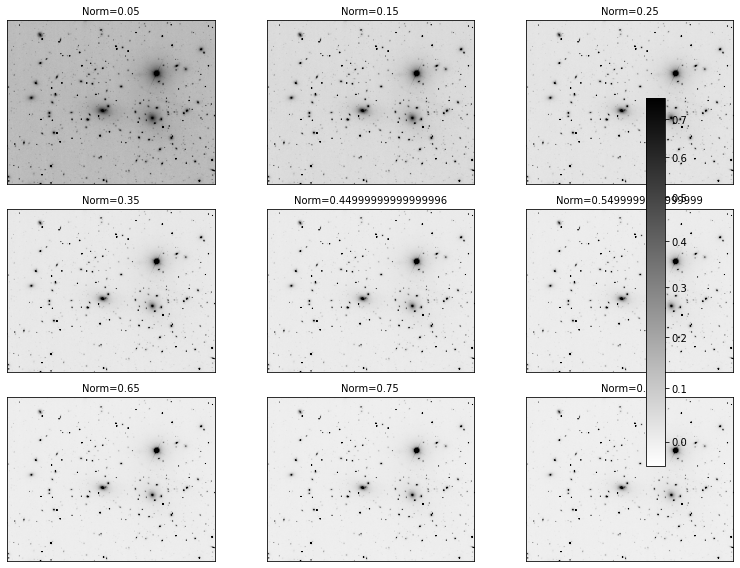

In [7]:
# import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# from astropy.io import fits
# from astropy.visualization import ImageNormalize, AsinhStretch
# import numpy as np


min_val = 0.1
max_val = 99.8

# Bias and contrast settings to apply (9 combinations)
min_pc_values = np.linspace(0.2, 2, 3)
max_pc_values = np.linspace(99.6, 99.9, 3)
norm_values = np.linspace(0.05, 0.85, 9)
print(min_val, max_val, norm_values)

# Set up the figure and a 3x3 grid using GridSpec
fig = plt.figure(figsize=(11, 8))
gs = GridSpec(3, 3, figure=fig)

# Loop over bias and contrast combinations and plot each version of the image
# for i, min_val in enumerate(min_pc_values):
for i in range(0,3):
#     for j, max_val in enumerate(max_pc_values):
    for j in range(0,3):
        idx = (i*3)+j
        
        norm_value = float(norm_values[idx])
        print(idx, norm_value)
        # Apply asinh scaling using ImageNormalize and AsinhStretch
        norm = ImageNormalize(vmin=np.percentile(image_data, min_val), 
                              vmax=np.percentile(image_data, max_val), 
                              stretch=AsinhStretch(norm_value))
        
        # Get the subplot for this combination
        ax = fig.add_subplot(gs[i, j])

        # Plot the image with the adjusted data
        im = ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)

        # Set the title to show the values used
#         ax.set_title(f'Min={min_val}, Max={max_val}', fontsize=10)
        ax.set_title(f'Norm={norm_value}', fontsize=10)

        # Remove the axis ticks for clarity
        ax.set_xticks([])
        ax.set_yticks([])

# Add an overall colorbar
fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.03, pad=0.04)

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the figure
plt.show()


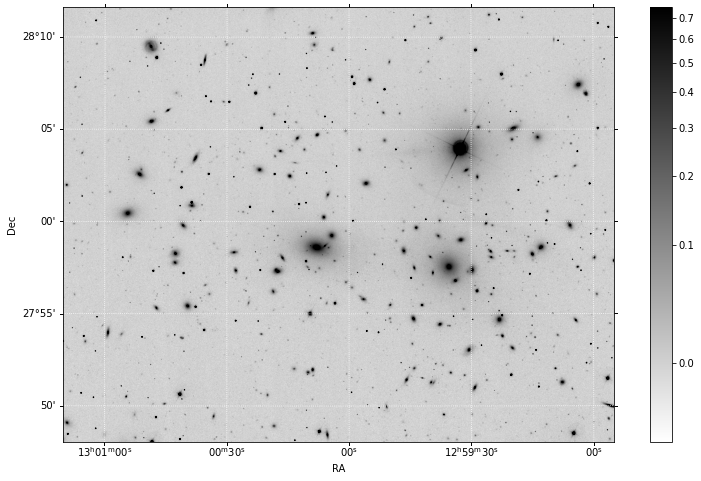

In [8]:
# Set up the plot with WCS projection
fig = plt.figure(figsize=(13, 8))
ax = plt.subplot(projection=wcs)

# Apply Asinh scaling for contrast adjustment
# Apply asinh scaling using ImageNormalize and AsinhStretch
norm = ImageNormalize(vmin=np.percentile(image_data, 0.1), 
                      vmax=np.percentile(image_data, 99.8), 
                      stretch=AsinhStretch(0.1))

# Display the image with WCS coordinates and asinh scaling
im = ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)

# Add a colorbar
plt.colorbar(im, ax=ax)

# Add WCS coordinates grid and labels
ax.coords.grid(True, color='white', ls='dotted')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')

# Show the plot
plt.show()


Create a function to add in a circle patch based on the WCS position (RA / Dec) and a passed radius in arcseconds. 

In [9]:
def add_effective_radius(ra_center, dec_center, radius_arcsec, ax, marker='-'):
    # RA and Dec coordinates define the circle's center in world coords

    # Circle radius in arcseconds and convert to degrees
    radius_deg = radius_arcsec / 3600.0  # Convert to degrees

    # Create a circle in WCS coordinates
    circle = Circle((ra_center, dec_center), radius_deg, edgecolor='red', facecolor='none',
                    transform=ax.get_transform('world'), linestyle = marker)

    # Add the circle to the plot
    ax.add_patch(circle)


Ensure that the main galaxy positions and labels are included in a dictionary.

In [10]:
# Galaxies named in that Coma image and that we also have fits files for. Including the non CCTS ones
galaxies = {'x_wcs':[195.161512, 195.070945, 195.178208, 195.178500, 195.20271, 195.03329, 195.22697, 195.15816, 195.21479, 195.09223, 195.06144, 
                     195.02662, 194.98334, 195.17021, 195.1183, 195.11654, 195.06884, 195.07367, 
                     195.0186, 195.03394, 194.94492, 194.88662, 194.89875, 194.87482, 194.81356, 
                     195.16568, 194.93502, 194.89215, 194.90793, 194.84732, 194.87844, 194.87252, 195.068827],
            'y_wcs':[28.014528, 28.063914, 27.971389, 27.963111, 28.090743, 28.078576, 28.007522, 28.057467, 28.042829, 28.046985, 28.041303, 
                     28.004151, 28.034712, 27.996626, 27.972417, 27.955991, 27.967525, 27.955255, 
                     27.987551, 27.976926, 27.973861, 27.983604, 27.959223, 27.956408, 27.970619, 
                     27.923945, 27.91247, 27.946749, 27.907223, 27.911492, 27.88422, 27.850143, 27.967532],
            'galname':[" ", " ", "IC 4042", "IC 4042A", "IC 4045", "IC 4012", "IC 4051", "IC 4040", "NGC 4908", "IC 4026", "IC 4021", 
                       "IC 4011", "NGC 4883", "IC 4041", "IC 4033", "IC 4030", "NGC 4884", "NGC 4898", 
                       "NGC 4882", "NGC 4889", "IC 3998", "NGC 4873", "NGC 4874", "NGC 4871", "NGC 4867", 
                       "NGC 4906", "NGC 4876", "NGC 4872", "NGC 4875", "NGC 4869", "IC 3973", "IC 3976", "NGC 4894"],
            'x':[0, 0, 0, 0, 1377.442, 2754.524, 3995.708, 371.300, 653.470, 1119.626, 1070.409, 4148.585, 1697.389, 
                 565.584, 2081.560, 3261.509, 3080.072, 3880.323, 3173.394, 2197.979, 2567.561, 1790.916, 
                 3348.130, 3861.473, 2589.826, 1807.256, 3089.419, 479.648, 2639.428, 2569.449, 1028.640, 
                 3506.983, 0],
            'y':[0, 0, 0, 0, 1850.557, 4112.752, 2528.394, 3987.619, 249.617, 3889.232, 1674.297, 3282.031, 2368.933, 
                 2182.412, 1000.930, 864.610, 4005.252, 3521.115, 4465.489, 3700.555, 3730.887, 3457.707, 
                 2339.341, 3785.076, 3835.160, 1241.374, 3290.489, 2805.688, 698.400, 629.842, 2206.118, 
                 2064.148, 0],
            'pointing':["n/a", "n/a", "n/a", "n/a", "1-1", "1-3", "2-0", "2-1", "2-1", "2-2", "2-3", "2-3", "2-4", "3-1", "3-2", 
                        "3-2", "3-2", "3-2", "3-3", "3-3", "3-4", "3-5", "3-5", "3-5", "3-6", "4-1", 
                        "4-4", "4-5", "4-5", "4-6", "5-5", "5-5", "n/a"]}
# Additional data for NGC 4883, NGC 4867, NGC 4869 and IC 4040 obtained from NED - SDSS deVaucouleurs effective radius
# 2007SDSS6.C...0000:
#           'gal_Re':[5.2, 18.87, 9.19, 4.74, 2.84, 5.24, 0.27],
#           'gal_Re':[8.2, 15.3, 19.4], Old values used, R.eff calculated in 2018 paper

galdata = {'name':["IC 4051", "NGC 4889", "NGC 4874", "NGC 4882", "NGC 4883", "NGC 4867", "NGC 4869", "IC 4040"],
           'gal_Re':[8.2, 15.3, 19.4, 4.5, 4.74, 2.84, 5.24, 0.27],
           'gcs_Re':[45.6, 91, 105, 0, 0, 0, 0, 0]
          }

# set the pixel scale
pix_scale = 0.0495
    
galdata['Re_pix_acs'] = [Re/pix_scale for Re in galdata['gal_Re']]
main_galaxies = pd.DataFrame(galdata)
galdata
main_galaxies3 = main_galaxies[:3]
main_galaxies3


,name,gal_Re,gcs_Re,Re_pix_acs
0,IC 4051,8.2,45.6,165.656566
1,NGC 4889,15.3,91.0,309.090909
2,NGC 4874,19.4,105.0,391.919192


In [11]:
name = 'NGC 4883'
i = galaxies['galname'].index(name)
print(galaxies['galname'][i], galaxies['x_wcs'][i], galaxies['y_wcs'][i] )


NGC 4883 194.98334 28.034712


Quick test of small angle formula converting from kpc to angular separation at the distance of the Coma cluster

In [12]:

# define a couple of helper functions and utilities used repeatedly
def bin_init(i, j, magbins):
    # Calculate the index for the bin
    bindex = j + (i * cols)

#     # Check if bindex is within the number of bins minus 1 (it should be!)
#     if bindex >= len(mag_bins) - 1:
#         return False, []

    # Define the bin start and end
    bin_start = mag_bins[bindex]
    bin_end = mag_bins[bindex + 1]

    return bindex, bin_start, bin_end

def get_wcs_range(wcs_1, image_data_1):
    
    # Determine the image extent in world coordinates
    wcs_world_extent = wcs_1.pixel_to_world([0, image_data_1.shape[1]], [0, image_data_1.shape[0]])

    # Determine the min and max coordinates in world coordinates
#     ra_min, ra_max = wcs_world_extent[0].value.min(), wcs_world_extent[0].value.max()
#     dec_min, dec_max = wcs_world_extent[1].value.min(), wcs_world_extent[1].value.max()
    
            
    # Set desired limits in WCS (RA, Dec)
    ra_min, ra_max = 195.28, 194.74  # RA limits in degrees
    dec_min, dec_max = 27.805, 28.19  # Dec limits in degrees
    
    return ra_min, ra_max, dec_min, dec_max

# import matplotlib.pyplot as plt
# from astropy.wcs import WCS
# from astropy.io import fits
# import numpy as np

def decimal_to_sexagesimal(decimal_angle):
    """
    Convert a decimal angle to sexagesimal format.

    Parameters:
    decimal_angle (float): Decimal degree value to be converted.

    Returns:
    tuple: A tuple representing (degrees, minutes, seconds)
    """
    # Create an Angle object from the input decimal degrees
    angle = Angle(decimal_angle, unit=u.deg)
    
    # Extract degrees (integer part of the angle)
    degrees = int(angle.deg)
    
    # Calculate fractional part of degrees to convert to sexagesimal minutes
    fractional_degrees = angle.deg - degrees
    sexagesimal_minutes = fractional_degrees * 60
    
    # Extract the integer part of sexagesimal minutes
    minutes = int(sexagesimal_minutes)
    
    # Calculate fractional part of minutes to convert to sexagesimal seconds
    fractional_minutes = sexagesimal_minutes - minutes
    sexagesimal_seconds = fractional_minutes * 60
    
    return degrees, minutes, sexagesimal_seconds

def sexagesimal_to_decimal(degrees, minutes, seconds):
    """
    Convert an angle from sexagesimal format (degrees, minutes, seconds) to decimal format.

    Parameters:
    degrees (int or float): Degrees part of the angle.
    minutes (int or float): Minutes part of the angle.
    seconds (int or float): Seconds part of the angle.

    Returns:
    float: The decimal representation of the angle.
    """
    # Convert the sexagesimal angle to decimal
    decimal_angle = degrees + (minutes / 60) + (seconds / 3600)
    print(f"{degrees}° {minutes}' {seconds}'' in decimal is: {decimal_angle:.6f} degrees")
    
    return decimal_angle

def add_scale_bar(ax, wcs, length_arcsec, label="1 arcmin", color='white', fontsize=12):
    """
    Add a scale bar (line) to a WCS-based Matplotlib image plot.

    Parameters:
    ax (matplotlib.axes._subplots.AxesSubplot): The axes object where the image is plotted.
    wcs (astropy.wcs.WCS): The WCS object for the image.
    length_arcsec (float): The length of the scale bar in arcseconds.
    label (str): The text label for the scale bar (default is '1 arcmin').
    color (str): Color of the scale bar and text (default is 'white').
    fontsize (int): Font size of the label (default is 12).
    """
    # Get the center of the image in pixel coordinates
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    center_x = (0.1 * (xlim[1] - xlim[0])) + xlim[0]  # Position scale bar at 10% of the plot width
    center_y = (0.1 * (ylim[1] - ylim[0])) + ylim[0]  # Position scale bar at 10% of the plot height
    
    # Convert the scale bar length from arcseconds to pixel length using the WCS
    pixel_scale = np.abs(wcs.wcs.cd[0][0]) * 3600  # Pixel scale in arcseconds per pixel
    length_pixels = length_arcsec / pixel_scale  # Length in pixels

    # Plot the scale bar as a line
    ax.plot([center_x, center_x + length_pixels], [center_y, center_y],
            color=color, lw=2, transform=ax.get_transform('pixel'))
    ax.plot([center_x, center_x], [center_y-(length_pixels/20), center_y+(length_pixels/20)],
            color=color, lw=2, transform=ax.get_transform('pixel'))
    ax.plot([center_x+length_pixels, center_x+length_pixels], [center_y-(length_pixels/20), center_y+(length_pixels/20)],
            color=color, lw=2, transform=ax.get_transform('pixel'))

    # Add a label to the scale bar
    ax.text(center_x + length_pixels / 2, center_y - 0.02 * (ylim[1] - ylim[0]),
            label, color=color, fontsize=fontsize, ha='center', va='top',
            transform=ax.get_transform('pixel'))

def get_angular_sep(d: float, D: float):
    """
    Get the angular separation in arcsec
    
    Parameters:
    d: spatial distance in parsecs
    D: radial distance to object, also in parsecs
    
    Returns: 
    angular seperation in arcseconds
    """
    return (d/D)*(180/np.pi)*3600

def get_spatial_dist(theta: float, D: float,):
    """
    Get the spatial distance in parsecs
    
    Parameters:
    Theta: anglular seperation in arcseconds
    D: radial distance to object, in parsecs
    
    Returns:
    spatial distance in parsecs
    """
    return (theta/3600)*(np.pi/180)*D

In [13]:
# Calculate a list of the angular distances (in arcseconds) for 5 kpc, 10 kpc, etc, at the 
# distance of the Coma Cluster (~100 Mpc)

d = [5, 10, 25, 50, 75, 100]
D = 100000

theta = [get_angular_sep(dist, 100000) for dist in d]

dist = 10000 # 10 kpc
D = 1e6
print(f'Angular separation at radial distance {D:5.0e} pc of spatial distance {dist:5.0e} is {get_angular_sep(dist, 100e6):5.1f} arcseconds.')


Angular separation at radial distance 1e+06 pc of spatial distance 1e+04 is  20.6 arcseconds.


Also do the same, but in reverse, given an angle (in arcsec by default) at the distance of the coma cluster (100Mpc) and calculate the actual spatial distance.

In [5]:
import numpy as np

def get_spatial_dist(theta: float, D: float,):
    return (theta/3600)*(np.pi/180)*D

get_spatial_dist(90, 100e6)  # gives spatial distance (in pc) for 20 arcsec at 100 Mpc (should be ~10,000 pc or ~ 10kpc)


43633.23129985824

In [15]:
d_1 = [get_spatial_dist(a, D) for a in theta]

d_1 

get_spatial_dist(2088, D)


10122.909661567111

Create the image to include
- background SDSS 'g' image
- RA / Dec grid (may be optional)
- axis ticks and labels
- set range of RA and Dec limits
- scatter of UCD (in blue)
- circles of radial distance 5, 10, 25, 50, 75, 100 kpc about three main ellipticals
- include galaxy labels

save to a .png image for inclusion in paper

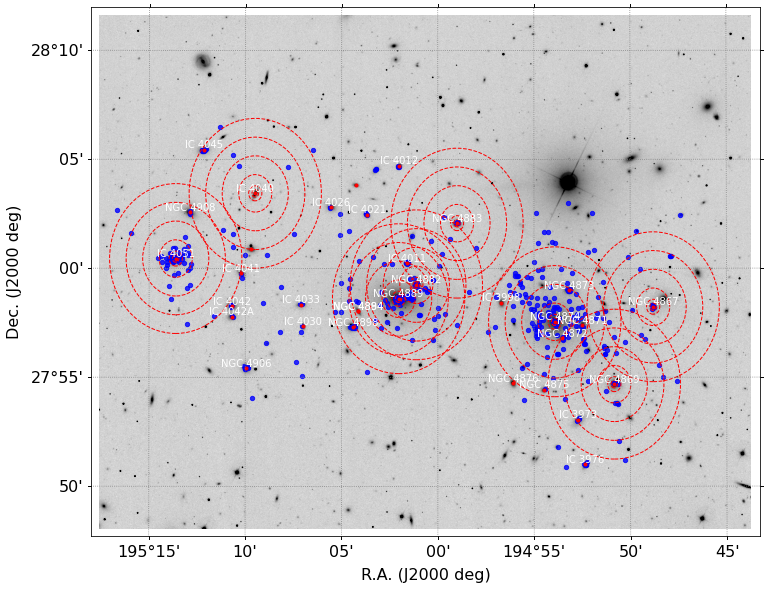

In [17]:
# Display the image with RA/Dec coordinates
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection=wcs)  # Use the WCS from the FITS file

# Apply asinh scaling using ImageNormalize and AsinhStretch
norm = ImageNormalize(vmin=np.percentile(image_data, 0.1), 
                      vmax=np.percentile(image_data, 99.8), 
                      stretch=AsinhStretch(0.1))

# Display the image with WCS coordinates and asinh scaling
im = ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)

# Customize the coordinate grid and labels
ax.coords.grid(color='gray', ls='dotted')
ax.coords[0].set_axislabel('R.A. (J2000 deg)', fontsize=fs)
ax.coords[1].set_axislabel('Dec. (J2000 deg)', fontsize=fs)

# Explicitly set the number of ticks
ax.coords[0].set_ticks(spacing=5 * u.arcmin)  # Set 5 RA ticks with 0.01 degree spacing
ax.coords[1].set_ticks(spacing=5 * u.arcmin)  # Set 5 Dec ticks with 0.01 degree spacing
# ax.coords[0].set_ticks(number=10)  # Set 5 RA ticks with 0.01 degree spacing
# ax.coords[1].set_ticks(number=10)  # Set 5 Dec ticks with 0.01 degree spacing

# Adjust the ticks and tick labels if necessary
ax.coords[0].set_major_formatter('dd:mm')
ax.coords[1].set_major_formatter('dd:mm')
ax.tick_params(axis='both', which='major', labelsize=fs)

# Set desired limits in WCS (RA, Dec)
ra_min, ra_max = 195.30, 194.72  # RA limits in degrees
dec_min, dec_max = 27.795, 28.20  # Dec limits in degrees

# ax.scatter(gcs_df['x_wcs'], gcs_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=2, alpha = 0.4, color = 'r')
ax.scatter(ucd_df['x_wcs'], ucd_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=75, alpha = 0.8, color = 'b')
pix_min = wcs.world_to_pixel_values(ra_min, dec_min)
pix_max = wcs.world_to_pixel_values(ra_max, dec_max)

# overlay galaxy names
for i,name in enumerate(galaxies['galname']):
    ax.scatter(galaxies['x_wcs'][i], galaxies['y_wcs'][i], transform=ax.get_transform('world'), color = 'r', marker = '.')
    ax.text(galaxies['x_wcs'][i], galaxies['y_wcs'][i], name, transform=ax.get_transform('world'), horizontalalignment = 'center', 
             verticalalignment = 'bottom', fontsize=10, color='w')
    if not (main_galaxies[main_galaxies['name']==name].empty):
#         add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], float(main_galaxies[main_galaxies['name']==name]['gal_Re']), ax, '-')
        [add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], ang, ax, '--') for j, ang in enumerate(theta)]
#             add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], theta[0], ax, '-')

# Set pixel limits directly
ax.set_xlim(pix_min[0], pix_max[0])
ax.set_ylim(pix_min[1], pix_max[1])

# Add a colorbar
# plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.1, label='Pixel Value')
# plt.title('Image with RA/Dec Coordinates')
path = 'figures/location/'
plt.savefig(f'{path}Coma_UCDs_Location_radial.png', bbox_inches='tight', format='png', dpi=200)
plt.show()


Above code creates an overlay with UCDs and radial rings to indicate distance from the galaxy centre. However, it may be better to relate the overlay to the effective radius of the galaxy, so this will be covered in the cell below.

<ipython-input-18-483134a19203>:44: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ang = float(main_galaxies[main_galaxies['name']==name]['gal_Re'])


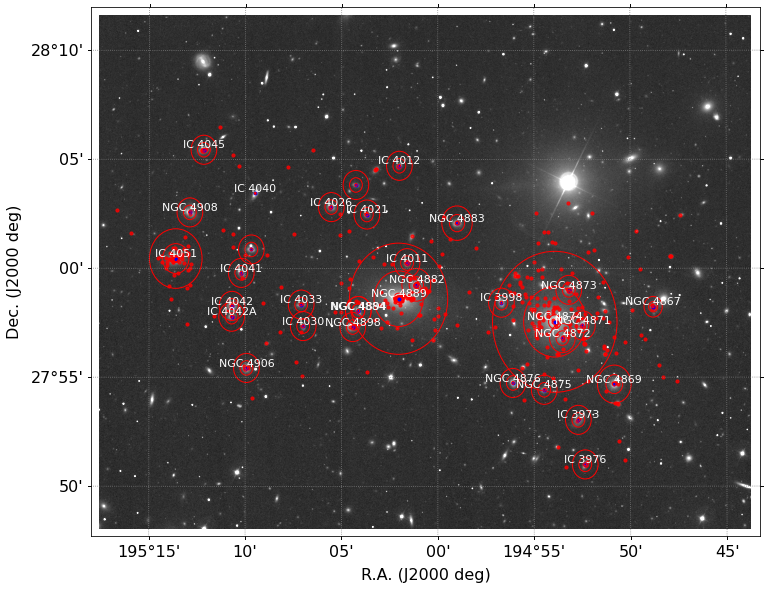

In [18]:
# Display the image with RA/Dec coordinates
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection=wcs)  # Use the WCS from the FITS file

# Apply asinh scaling using ImageNormalize and AsinhStretch
norm = ImageNormalize(vmin=np.percentile(image_data, 0.1), 
                      vmax=np.percentile(image_data, 99.8), 
                      stretch=AsinhStretch(0.1))

# Display the image with WCS coordinates and asinh scaling
im = ax.imshow(image_data, origin='lower', cmap='gray', norm=norm)

# Customize the coordinate grid and labels
ax.coords.grid(color='gray', ls='dotted')
ax.coords[0].set_axislabel('R.A. (J2000 deg)', fontsize=fs)
ax.coords[1].set_axislabel('Dec. (J2000 deg)', fontsize=fs)

# Explicitly set the number of ticks
ax.coords[0].set_ticks(spacing=5 * u.arcmin)  # Set 5 RA ticks with 0.01 degree spacing
ax.coords[1].set_ticks(spacing=5 * u.arcmin)  # Set 5 Dec ticks with 0.01 degree spacing
# ax.coords[0].set_ticks(number=10)  # Set 5 RA ticks with 0.01 degree spacing
# ax.coords[1].set_ticks(number=10)  # Set 5 Dec ticks with 0.01 degree spacing

# Adjust the ticks and tick labels if necessary
ax.coords[0].set_major_formatter('dd:mm')
ax.coords[1].set_major_formatter('dd:mm')
ax.tick_params(axis='both', which='major', labelsize=fs)

# Set desired limits in WCS (RA, Dec)
ra_min, ra_max = 195.30, 194.72  # RA limits in degrees
dec_min, dec_max = 27.795, 28.20  # Dec limits in degrees

# ax.scatter(gcs_df['x_wcs'], gcs_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=2, alpha = 0.4, color = 'r')
ax.scatter(ucd_df['x_wcs'], ucd_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=40, alpha = 0.8, color = 'r')
pix_min = wcs.world_to_pixel_values(ra_min, dec_min)
pix_max = wcs.world_to_pixel_values(ra_max, dec_max)

# overlay galaxy names
for i,name in enumerate(galaxies['galname']):
    ax.scatter(galaxies['x_wcs'][i], galaxies['y_wcs'][i], transform=ax.get_transform('world'), color = 'b', marker = '.')
    ax.text(galaxies['x_wcs'][i], galaxies['y_wcs'][i], name, transform=ax.get_transform('world'), horizontalalignment = 'center', 
             verticalalignment = 'bottom', fontsize=11, color='w')
    if not (main_galaxies[main_galaxies['name']==name].empty):
        ang = float(main_galaxies[main_galaxies['name']==name]['gal_Re'])
    else:
        ang = 4.0
    [add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], a, ax, '-') for a in [ang, ang*5, ang*10]]

#         add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], float(main_galaxies[main_galaxies['name']==name]['gal_Re']), ax, '-')
#         add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], float(main_galaxies[main_galaxies['name']==name]['gal_Re'])*5, ax, '-')
#         add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], float(main_galaxies[main_galaxies['name']==name]['gal_Re'])*10, ax, '-')
#     else:
#         [add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], a, ax, '-') for a in [5, 25, 50]]

#     [add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], ang, ax, '--') for j, ang in enumerate(theta)]
#     add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], theta[0], ax, '-')


# Set pixel limits directly
ax.set_xlim(pix_min[0], pix_max[0])
ax.set_ylim(pix_min[1], pix_max[1])

# Add a colorbar
# plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.1, label='Pixel Value')
# plt.title('Image with RA/Dec Coordinates')
path = 'figures/location/'
plt.savefig(f'{path}Coma_UCDs_Location_Re.png', bbox_inches='tight', format='png', dpi=200)
plt.show()


### Load data based on Hoyos et al. 2011 and Trentham 2014

Augmentended data merge produced based on Hoyos et al. 2011 and Trentham 2014 in separate Jupyter notebook "Coma_catalog_manipulate.pynb". This loads the catalogs, merges on position and used the effective radius, Re, data from HST ACS to determine galaxy sizes.

These are can then be used to set the radius in the below plot and will be used, by exclusion, to determine the intracluster GC population and IGCG fraction.

In [19]:
# Read in csv file, header set already in row 0
inFileName = "data/augmented_data.csv"
galaxyData_init = pd.read_csv(inFileName)

# index = galaxyData_init[galaxyData_init['index']==28].index
# print(index)
# print(galaxyData_init.loc[index, 'v'],galaxyData_init.loc[index, 'z2007'])
# galaxyData_init.loc[index, 'z2007']=0.0247
# print(galaxyData_init.loc[index, 'v'],galaxyData_init.loc[index, 'z2007'])

# galaxyData_init.iloc[index]['z2007']
# # Force the column to float and set invalid entries to NaN
galaxyData_init['z2007'] = pd.to_numeric(galaxyData_init['z2007'], errors='coerce')

galaxyData_1 = galaxyData_init.sort_values(by=['ReGF_arcsec'],ascending=False)

galaxyData_1.columns

Index(['index', 'pointing', 'point_pos', 'x', 'y', 'galaxy type', 'duplicate',
       'vknownafterHectospec2007', 'sub_rating', 'ip_mag', 'ap_mag', 'RA',
       'Dec', 'radial', 'v', 'v_ref', 'z2007', 'Comments', 'RTP_comments',
       'COMAi', 'DEJ2000', 'EVIG2D', 'EVIGF', 'F814W', 'F814WG2D', 'F814WGF',
       'PAG2D', 'PAGF', 'RAJ2000', 'RFFG2D', 'RFFGF', 'ReG2D', 'ReGF',
       'SuBrG2D', 'SuBrGF', 'SuBrmG2D', 'SuBrmGF', 'e_F814WG2D', 'e_F814WGF',
       'e_PAG2D', 'e_PAGF', 'e_ReG2D', 'e_ReGF', 'e_ellG2D', 'e_ellGF',
       'e_nG2D', 'e_nGF', 'ellG2D', 'ellGF', 'nG2D', 'nGF', 'recno',
       'ReG2D_arcsec', 'ReGF_arcsec'],
      dtype='object')

### Set size of galaxy sample included

To determine if there is a relationship between the brightest (\~largest) and dimmest (\~smallest) in respect of the ICGC and ICUCD fractions, and if the relationship is constant, we wil copy the dataframe with filtering and repeat the process. Can also try this using F814W filter value to test for brightest and dimmest, although this is likely to be similar.


In [20]:
# Take a copy of galaxyData
galaxyData_ALL = galaxyData_1

# find median and mean value for size estimate
median_size = np.median(galaxyData_1['ReGF'])
mean_size = np.mean(galaxyData_1['ReGF'])

# now get copy with big and small
galaxyData_BIG = galaxyData_1[galaxyData_1['ReGF']>mean_size]
galaxyData_SMALL = galaxyData_1[galaxyData_1['ReGF']<mean_size]

idlabel = 'all' 

if idlabel == 'big':
    galaxyData = galaxyData_BIG
elif idlabel == 'small':
    galaxyData = galaxyData_SMALL
elif idlabel == 'all':
    galaxyData = galaxyData_ALL
else:
    print('Please check value of "idlabel".')


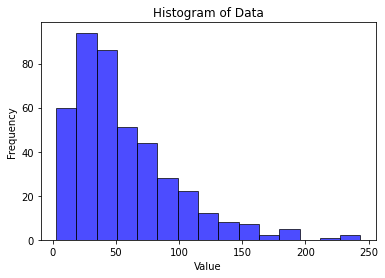

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Create a histogram
plt.hist(galaxyData['ReGF'], bins=15, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Data')
plt.show()

In [22]:
galaxyData.columns

Index(['index', 'pointing', 'point_pos', 'x', 'y', 'galaxy type', 'duplicate',
       'vknownafterHectospec2007', 'sub_rating', 'ip_mag', 'ap_mag', 'RA',
       'Dec', 'radial', 'v', 'v_ref', 'z2007', 'Comments', 'RTP_comments',
       'COMAi', 'DEJ2000', 'EVIG2D', 'EVIGF', 'F814W', 'F814WG2D', 'F814WGF',
       'PAG2D', 'PAGF', 'RAJ2000', 'RFFG2D', 'RFFGF', 'ReG2D', 'ReGF',
       'SuBrG2D', 'SuBrGF', 'SuBrmG2D', 'SuBrmGF', 'e_F814WG2D', 'e_F814WGF',
       'e_PAG2D', 'e_PAGF', 'e_ReG2D', 'e_ReGF', 'e_ellG2D', 'e_ellGF',
       'e_nG2D', 'e_nGF', 'ellG2D', 'ellGF', 'nG2D', 'nGF', 'recno',
       'ReG2D_arcsec', 'ReGF_arcsec'],
      dtype='object')

<ipython-input-23-40024015a03c>:41: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ang = float(main_galaxies[main_galaxies['name']==name]['gal_Re'])


size is: 196


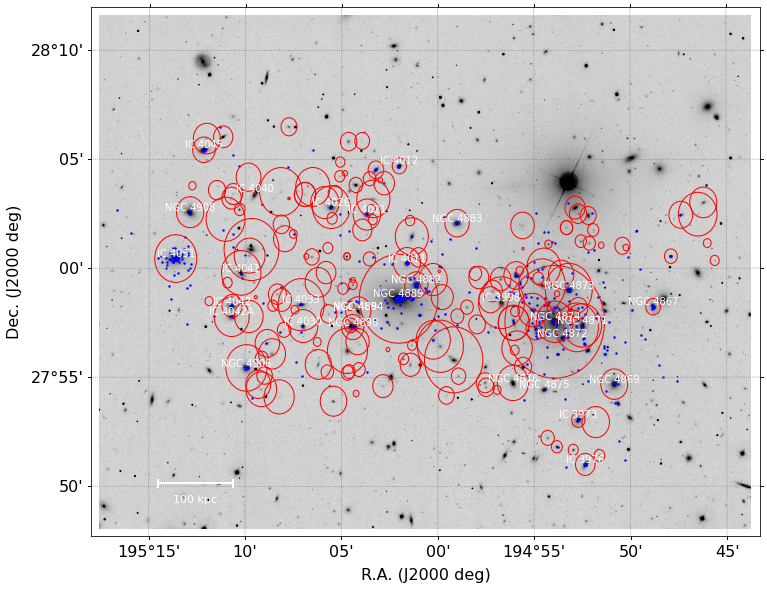

In [23]:
# Display the image with RA/Dec coordinates
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection=wcs)  # Use the WCS from the FITS file

# Apply asinh scaling using ImageNormalize and AsinhStretch
norm = ImageNormalize(vmin=np.percentile(image_data, 0.1), 
                      vmax=np.percentile(image_data, 99.8), 
                      stretch=AsinhStretch(0.1))

# Display the image with WCS coordinates and asinh scaling
im = ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)

# Customize the coordinate grid and labels
ax.coords.grid(color='gray', ls='dotted')
ax.coords[0].set_axislabel('R.A. (J2000 deg)', fontsize=fs)
ax.coords[1].set_axislabel('Dec. (J2000 deg)', fontsize=fs)

# Explicitly set the number of ticks
ax.coords[0].set_ticks(spacing=5 * u.arcmin)  # Set 5 RA ticks with 0.01 degree spacing
ax.coords[1].set_ticks(spacing=5 * u.arcmin)  # Set 5 Dec ticks with 0.01 degree spacing

# Adjust the ticks and tick labels if necessary
ax.coords[0].set_major_formatter('dd:mm')
ax.coords[1].set_major_formatter('dd:mm')
ax.tick_params(axis='both', which='major', labelsize=fs)

# Set desired limits in WCS (RA, Dec)
ra_min, ra_max = 195.30, 194.72  # RA limits in degrees or 13h01m12s to 12h58m52.8s
dec_min, dec_max = 27.795, 28.20  # Dec limits in degrees

# ax.scatter(gcs_df['x_wcs'], gcs_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=2, alpha = 0.4, color = 'r')
ax.scatter(ucd_df['x_wcs'], ucd_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=10, alpha = 0.8, color = 'b')
pix_min = wcs.world_to_pixel_values(ra_min, dec_min)
pix_max = wcs.world_to_pixel_values(ra_max, dec_max)

# overlay galaxy names
for i,name in enumerate(galaxies['galname']):
    ax.text(galaxies['x_wcs'][i], galaxies['y_wcs'][i], name, transform=ax.get_transform('world'), horizontalalignment = 'center', 
             verticalalignment = 'bottom', fontsize=10, color='white')
    if not (main_galaxies[main_galaxies['name']==name].empty):
        ang = float(main_galaxies[main_galaxies['name']==name]['gal_Re'])
        if idlabel != 'small':
            add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], ang*8, ax, '-')

min_size = 0.25  # min size of effective radius in arcsec
min_z = 0.015
max_z = 0.032

maxsize_galaxyData = galaxyData[(galaxyData['ReGF_arcsec']>min_size) & ((galaxyData['z2007']>min_z) & (galaxyData['z2007']<max_z))]

print('size is:', len(maxsize_galaxyData))
for index, row in maxsize_galaxyData.iterrows():
    add_effective_radius(row['RAJ2000'], row['DEJ2000'], row['ReGF_arcsec']*8, ax, '-')

# Set pixel limits directly
ax.set_xlim(pix_min[0], pix_max[0])
ax.set_ylim(pix_min[1], pix_max[1])

# Add a scale marker (e.g., 60 arcseconds = 1 arcminute)
length_arcsec = get_angular_sep(100e3, 100e6)
add_scale_bar(ax, wcs, length_arcsec=length_arcsec, label="100 kpc", color='white', fontsize=11)  

# Add a colorbar
path = 'figures/location/'
plt.savefig(f'{path}Coma_UCDs_Location_Re_W_gals_{idlabel}.png', bbox_inches='tight', format='png', dpi=200)
plt.show()


## Intracluster UCDs

To efficiently count the number of UCDs that are not within a certain multiple of the effective radius of galaxies, these are steps:


Create a function to convert Right Ascension (RA) and Declination (Dec) values from decimal format into the string format hhmmss.sss_ddmmss.ss for COMAid

In [24]:
def coords_to_id_str(ra, dec):
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    # RA and Dec, strings in decimal degrees
    ra_decimal = float(ra)  # Right Ascension in degrees
    dec_decimal = float(dec)  # Declination in degrees

    # Create a SkyCoord object
    coord = SkyCoord(ra=ra_decimal*u.deg, dec=dec_decimal*u.deg)

    # Convert to 'hhmmss.sss' for RA and 'ddmmss.ss' for Dec
    ra_str = coord.ra.to_string(unit=u.hour, sep='', pad=True, precision=3)  # 'hhmmss.sss'
    dec_str = coord.dec.to_string(sep='', pad=True, precision=2)  # 'ddmmss.ss'

        # Modify the sign: 'p' for positive, 'n' for negative
    if coord.dec.deg >= 0:
        dec_str = 'p' + dec_str  # prepend 'p' for positive Dec
    else:
        dec_str = 'n' + dec_str[1:]  # replace '-' with 'n' for negative Dec
        
    # Combine RA and Dec into the final format 'hhmmss.sss_ddmmss.ss'
    formatted_coord = f"{ra_str}{dec_str}"

    return formatted_coord


First consolidate all the filtered galaxy data to a consistent format.

In [25]:
maxsize_galaxyData[maxsize_galaxyData['sub_rating']<=3.0]


,index,pointing,point_pos,x,y,galaxy type,duplicate,vknownafterHectospec2007,sub_rating,ip_mag,...,e_ellGF,e_nG2D,e_nGF,ellG2D,ellGF,nG2D,nGF,recno,ReG2D_arcsec,ReGF_arcsec
383,463,63.0,outer,2135.0,1146,4,NaN,y,0.0,15.50,...,0.001,0.00,0.07,NaN,0.147,NaN,2.45,4732,NaN,12.053250
323,390,25.0,inner,1199.0,389,1,NaN,y,0.0,NaN,...,0.000,0.00,0.07,NaN,0.381,NaN,3.68,8577,NaN,11.362230
57,69,8.0,Intermediate,3350.0,3138,-5,NaN,y,0.0,14.84,...,0.000,0.12,0.07,0.347,0.436,4.72,4.06,6794,16.821090,10.676655
220,269,19.0,inner,1804.0,3458,-5,NaN,y,0.0,14.09,...,0.000,0.11,0.06,0.202,0.222,5.68,4.53,2077,12.822975,9.142155
224,273,19.0,inner,1226.0,2070,-5,NaN,y,0.0,15.70,...,0.000,0.13,0.06,0.352,0.339,3.93,3.34,2027,12.329460,9.075330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,143,12.0,inner,2966.0,1607,-5,NaN,NaN,0.0,NaN,...,0.006,0.11,0.05,0.026,0.021,4.95,4.56,2976,0.432630,0.435600
201,244,18.0,inner,752.0,563,-1,NaN,,0.0,90.81,...,0.003,0.10,0.04,0.024,0.025,1.54,1.63,3816,0.404910,0.429660
72,89,9.0,Intermediate,175.0,1704,13,NaN,NaN,0.0,21.80,...,0.040,0.00,0.09,NaN,0.109,NaN,10.00,211,NaN,0.411840
21,28,2.0,Intermediate,4095.0,1841,13,NaN,NaN,0.0,21.71,...,0.040,0.00,0.09,NaN,0.109,NaN,10.00,211,NaN,0.411840


In [26]:
# List of columns we want to copy
columns_to_copy = [ 'COMAi', 'Comments', 'RAJ2000', 'DEJ2000', 'ReGF_arcsec']

# Create a new DataFrame with selected columns
main_galaxies_df = maxsize_galaxyData[columns_to_copy].copy()

new_columns = { 'COMAi': 'id', 'Comments': 'Comments', 'RAJ2000': 'RA', 'DEJ2000': 'Dec', 'ReGF_arcsec': 'Re'}
main_galaxies_df.rename(columns=new_columns, inplace=True)
main_galaxies_df.reset_index(drop=True, inplace=True)

for i,name in enumerate(galaxies['galname']):
    if not (main_galaxies[main_galaxies['name']==name].empty):
        # Now get index of entry in main galaxies DF in case! (we already  have index 'i' in general galaxy list)
        ind = main_galaxies[main_galaxies['name']==name].index[0]
        # get ra and dec, and convert to a formated string for Coma ID
        ra, dec = galaxies['x_wcs'][i], galaxies['y_wcs'][i]
        ComaID = coords_to_id_str(ra, dec)
        # get effective radius angle
        ang = float(main_galaxies[main_galaxies['name']==name]['gal_Re'])
        pix = float(main_galaxies[main_galaxies['name']==name]['Re_pix_acs'])
        
        # now get copy with big and small
        # median_size SHOULD BE SET a few cells above
        print(median_size, ang, pix, idlabel)
        if (pix>median_size and idlabel=='big') or (pix<median_size and idlabel=='small') or idlabel=='all':

            # Create new row to append (note: match the column names)
            new_row = pd.DataFrame({'id': ComaID, 'Comments': name, 'RA': ra, 'Dec': dec, 'Re': ang}, index=[0])
            # Append the new row using concat
            main_galaxies_df = pd.concat([main_galaxies_df, new_row], ignore_index=True)

        
main_galaxies_df


44.285 8.2 165.65656565656565 all
44.285 0.27 5.454545454545455 all
44.285 4.74 95.75757575757575 all
44.285 4.5 90.9090909090909 all
44.285 15.3 309.09090909090907 all
44.285 19.4 391.91919191919186 all
44.285 2.84 57.37373737373737 all
44.285 5.24 105.85858585858585 all


<ipython-input-26-510d69130038>:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ang = float(main_galaxies[main_galaxies['name']==name]['gal_Re'])
<ipython-input-26-510d69130038>:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pix = float(main_galaxies[main_galaxies['name']==name]['Re_pix_acs'])


,id,Comments,RA,Dec,Re
0,125634.648p271339.03,KUG 1254+274,194.144363,27.227511,12.053250
1,125956.707p275548.62,NaN,194.986282,27.930174,11.362230
2,13038.731p28052.22,NaN,195.161377,28.014507,10.676655
3,125932.789p275900.95,NGC 4873,194.886627,27.983599,9.142155
4,125938.323p275913.84,NaN,194.909683,27.987181,9.075330
...,...,...,...,...,...
199,130004.464p275915.18,NGC 4882,195.018600,27.987551,4.500000
200,130008.146p275836.93,NGC 4889,195.033940,27.976926,15.300000
201,125935.700p275733.20,NGC 4874,194.898750,27.959223,19.400000
202,125915.254p275814.23,NGC 4867,194.813560,27.970619,2.840000


In [27]:
main_galaxies_df


,id,Comments,RA,Dec,Re
0,125634.648p271339.03,KUG 1254+274,194.144363,27.227511,12.053250
1,125956.707p275548.62,NaN,194.986282,27.930174,11.362230
2,13038.731p28052.22,NaN,195.161377,28.014507,10.676655
3,125932.789p275900.95,NGC 4873,194.886627,27.983599,9.142155
4,125938.323p275913.84,NaN,194.909683,27.987181,9.075330
...,...,...,...,...,...
199,130004.464p275915.18,NGC 4882,195.018600,27.987551,4.500000
200,130008.146p275836.93,NGC 4889,195.033940,27.976926,15.300000
201,125935.700p275733.20,NGC 4874,194.898750,27.959223,19.400000
202,125915.254p275814.23,NGC 4867,194.813560,27.970619,2.840000


Now check info on UCD data. Only need position at this stage, but will add a flag to Dataframe for each UCD which can be set based on proximity to galaxy.

Initialise to **True** and then set to **False** if inside *Re* x multiple. No need to check again once discounted as being ICUCD.

Perhaps do the same for GCs.

In [28]:
gcs_df.loc[:,'ICGC'] = True
# ucd_df

gcs_df
gcs_df.loc[:,['x_wcs', 'y_wcs']] = gcs_df[['x_wcs', 'y_wcs']].astype(float)
gcs_df.loc[:,'x_wcs'] = pd.to_numeric(gcs_df['x_wcs'], errors='coerce')
gcs_df.loc[:,'y_wcs'] = pd.to_numeric(gcs_df['y_wcs'], errors='coerce')

print(gcs_df.dtypes)

ucds_coord = SkyCoord(ra=gcs_df['x_wcs'].values*u.deg, dec=gcs_df['y_wcs'].values*u.deg)



x_wcs          float64
y_wcs          float64
flux_814       float64
flux_475       float64
mag_814        float64
mag_475        float64
color          float64
pointing        object
x              float64
y              float64
type            object
x_wcs_f        float64
y_wcs_f        float64
gc_type_f       object
pointing_f      object
Unnamed: 15    float64
ICGC              bool
dtype: object


<ipython-input-28-2b4f1691b78f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gcs_df.loc[:,'ICGC'] = True


In [29]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd

# List to store valid SkyCoord objects or results
coords = []

# Loop through the DataFrame rows
for index, row in gcs_df.iterrows():
    try:
        # Attempt to create SkyCoord object for each row
        coord = SkyCoord(ra=float(row['x_wcs'])*u.deg, dec=float(row['y_wcs'])*u.deg)
        coords.append(coord)
    except (ValueError, TypeError) as e:
        # Log or skip bad data
        print(f"Error at index {index}: {e}")
        coords.append(None)  # Optionally append None or skip

# Print valid SkyCoord objects
for c in coords:
    print(c)


<SkyCoord (ICRS): (ra, dec) in deg
    (194.09794, 27.244074)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.09828, 27.212645)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.09871, 27.21272)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.09916, 27.222516)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.09917, 27.213105)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.09971, 27.2075)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.09979, 27.235885)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.09986, 27.222173)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10028, 27.227642)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10047, 27.227568)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10141, 27.233344)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10161, 27.219408)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10181, 27.198713)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10238, 27.198943)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10435, 27.246508)>
<SkyCoord (ICRS): (ra, dec) in deg
    (194.10483, 27.2206

Now define a function to do a comparison between the position of the objects in the dataframe and the 

In [30]:
def calc_ICfrac(gal_df, css_df, Re_mult, flag_col, verbose=False):
    from astropy.coordinates import SkyCoord
    # Reset IC flag on DF
    css_df.loc[:,flag_col] = True
    
    # Convert to SkyCoord objects for easy distance calculations
    galaxies_coord = SkyCoord(ra=gal_df['RA'].values*u.deg, dec=gal_df['Dec'].values*u.deg)
    ucds_coord = SkyCoord(ra=css_df['x_wcs'].values*u.deg, dec=css_df['y_wcs'].values*u.deg)

    # Define the multiples of effective radius you want to check
    radius_multiple = Re_mult  # or whatever value

    # Loop through galaxies and set UCD ICUCD flag based on distance from each galaxy
    count_outside_radius = 0
    for idx, galaxy in gal_df.iterrows():
        galaxy_radius = galaxy['Re'] * radius_multiple  # in arcseconds or the unit used for the radius
        galaxy_coord = galaxies_coord[idx]

        # Calculate separations between this galaxy and all UCDs
        separations = galaxy_coord.separation(ucds_coord).arcsec  # or use another unit

        # Find UCDs outside the multiple of effective radius - these ane NOT ICUCDs
        ucds_outside = separations > galaxy_radius
        css_df.loc[:,flag_col] = (css_df[flag_col] & ucds_outside)

        if verbose:
            print(f'UCDs outside = {np.sum(ucds_outside)}, ', end='')
            print(f'Running total = {np.sum(css_df[flag_col])}')
    
    return np.sum(css_df[flag_col])

def calc_ICfrac_bootstrap(gal_df, css_df, Re_mult, flag_col, n_bootstrap=1000, verbose=False):
    """
    Calculate the fraction of UCDs and GCs outside a multiple of the effective radius,
    with bootstrap uncertainty estimation.
    
    Parameters:
    gal_df : DataFrame
        DataFrame containing galaxy positions and effective radii.
    css_df : DataFrame
        DataFrame containing UCD/GC positions.
    Re_mult : float
        The multiple of the effective radius to consider.
    flag_col : str
        Column name in css_df where in-cluster status (True/False) is stored.
    n_bootstrap : int, optional
        Number of bootstrap resamples (default is 1000).
    verbose : bool, optional
        Print progress (default is False).
    
    Returns:
    mean_frac : float
        Mean fraction of objects outside the defined radius.
    std_frac : float
        Bootstrap standard deviation (uncertainty) of the fraction.
    """
    # Reset IC flag on DF
    css_df.loc[:, flag_col] = True
    
    # Convert to SkyCoord objects for easy distance calculations
    galaxies_coord = SkyCoord(ra=gal_df['RA'].values * u.deg, dec=gal_df['Dec'].values * u.deg)
    ucds_coord = SkyCoord(ra=css_df['x_wcs'].values * u.deg, dec=css_df['y_wcs'].values * u.deg)
    
    # Loop through galaxies and update the flag based on distance
    for idx, galaxy in gal_df.iterrows():
        galaxy_radius = galaxy['Re'] * Re_mult  # in arcseconds
        galaxy_coord = galaxies_coord[idx]
        separations = galaxy_coord.separation(ucds_coord).arcsec
        ucds_outside = separations > galaxy_radius
        css_df.loc[:, flag_col] = (css_df[flag_col] & ucds_outside)
    
    total_outside = np.sum(css_df[flag_col])
    total_objects = len(css_df)
    frac_outside = total_outside / total_objects
    
    # Bootstrap resampling
    bootstrap_fracs = []
    for _ in range(n_bootstrap):
        resample_idx = np.random.choice(len(css_df), size=len(css_df), replace=True)
        resampled_df = css_df.iloc[resample_idx]
#         poisson_weights = np.random.poisson(lam=1, size=len(css_df))  # Poisson-distributed weights
#         resampled_df = css_df.loc[css_df.index.repeat(poisson_weights)]
        frac_resampled = np.sum(resampled_df[flag_col]) / len(resampled_df)
        bootstrap_fracs.append(frac_resampled)
    
    mean_frac = np.mean(bootstrap_fracs)
    std_frac = np.std(bootstrap_fracs)
    uncertainty = 3 * (std_frac / np.sqrt(n_bootstrap))  # 3σ standard error on the mean
    
    if verbose:
        print(f'Mean fraction outside: {mean_frac:.4f} ± {uncertainty:.4f}')
    
    return mean_frac*total_objects, uncertainty*total_objects


In [30]:
IC_df = pd.DataFrame()

total_gcs = len(gcs_df)
print(total_gcs)
for Re_mult in range(1, 11):
    ICGC_mean, ICGC_err = calc_ICfrac_bootstrap(main_galaxies_df, gcs_df, Re_mult, 'ICGC', verbose=False)
    frac = ICGC_mean/total_gcs
    new_row = pd.DataFrame({'type': ['ICGC'], 'Re_mult': [Re_mult], 'count': [ICGC_mean], 'count_err': [ICGC_err], 'frac': [frac]})
    IC_df = pd.concat([IC_df, new_row], ignore_index = True)
    
    # The final count of GCs outside the radius
    print(f"Total GCs outside {Re_mult:>2d}x Re of all galaxies: {ICGC_mean:>5.0f}({ICGC_err:>5.3f}) of {total_gcs} (Frac: {ICGC_mean/total_gcs:5.2f})")

total_ucds = len(ucd_df)
print(total_ucds)
for Re_mult in range(1, 11):
    ICUCD_mean, ICUCD_err = calc_ICfrac_bootstrap(main_galaxies_df, ucd_df, Re_mult, 'ICUCD', verbose=False)
    frac = ICUCD_mean/total_ucds
    new_row = pd.DataFrame({'type': ['ICUCD'], 'Re_mult': [Re_mult], 'count': [ICUCD_mean], 'count_err': [ICUCD_err], 'frac': [frac]})
    IC_df = pd.concat([IC_df, new_row], ignore_index = True)
    
    # The final count of UCDs outside the radius
    print(f"Total UCDs outside {Re_mult:>2d}x Re of all galaxies: {ICUCD_mean:>5.0f}({ICUCD_err:>5.3f}) of {total_ucds} (Frac: {ICUCD_mean/total_ucds:5.2f})")

IC_df

  

22828
Total GCs outside  1x Re of all galaxies: 21467(3.404) of 22828 (Frac:  0.94)
Total GCs outside  2x Re of all galaxies: 18436(5.889) of 22828 (Frac:  0.81)
Total GCs outside  3x Re of all galaxies: 15159(6.816) of 22828 (Frac:  0.66)
Total GCs outside  4x Re of all galaxies: 12284(7.181) of 22828 (Frac:  0.54)
Total GCs outside  5x Re of all galaxies:  9970(7.095) of 22828 (Frac:  0.44)
Total GCs outside  6x Re of all galaxies:  8136(7.012) of 22828 (Frac:  0.36)
Total GCs outside  7x Re of all galaxies:  6685(6.504) of 22828 (Frac:  0.29)
Total GCs outside  8x Re of all galaxies:  5478(6.114) of 22828 (Frac:  0.24)
Total GCs outside  9x Re of all galaxies:  4426(5.519) of 22828 (Frac:  0.19)
Total GCs outside 10x Re of all galaxies:  3569(5.322) of 22828 (Frac:  0.16)
523


<ipython-input-29-e09d040f1c94>:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  css_df.loc[:, flag_col] = True


Total UCDs outside  1x Re of all galaxies:   306(1.040) of 523 (Frac:  0.58)
Total UCDs outside  2x Re of all galaxies:   252(1.122) of 523 (Frac:  0.48)
Total UCDs outside  3x Re of all galaxies:   195(1.022) of 523 (Frac:  0.37)
Total UCDs outside  4x Re of all galaxies:   172(1.019) of 523 (Frac:  0.33)
Total UCDs outside  5x Re of all galaxies:   135(0.941) of 523 (Frac:  0.26)
Total UCDs outside  6x Re of all galaxies:   102(0.848) of 523 (Frac:  0.20)
Total UCDs outside  7x Re of all galaxies:    93(0.802) of 523 (Frac:  0.18)
Total UCDs outside  8x Re of all galaxies:    75(0.797) of 523 (Frac:  0.14)
Total UCDs outside  9x Re of all galaxies:    61(0.705) of 523 (Frac:  0.12)
Total UCDs outside 10x Re of all galaxies:    47(0.618) of 523 (Frac:  0.09)


,type,Re_mult,count,count_err,frac
0,ICGC,1,21466.728,3.404404,0.940368
1,ICGC,2,18436.171,5.889305,0.807612
2,ICGC,3,15159.287,6.815871,0.664065
3,ICGC,4,12283.956,7.180762,0.538109
4,ICGC,5,9970.415,7.094523,0.436763
5,ICGC,6,8136.012,7.012442,0.356405
6,ICGC,7,6685.166,6.504135,0.292849
7,ICGC,8,5477.914,6.114177,0.239965
8,ICGC,9,4426.481,5.518555,0.193906
9,ICGC,10,3568.704,5.321863,0.156330


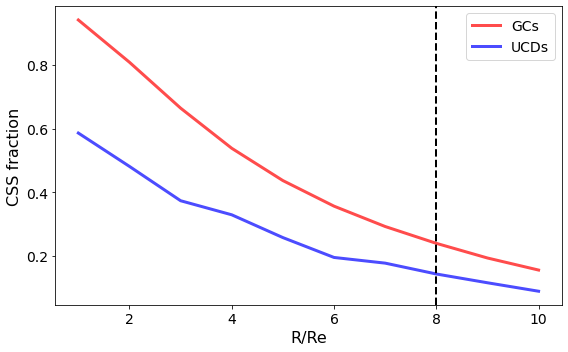

Created figures/intracluster/Coma_GC_UCDs_IC_fraction_all.png


In [106]:
fs = 16
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(IC_df[IC_df['type']=='ICGC']['Re_mult'], IC_df[IC_df['type']=='ICGC']['frac'], label='GCs', color='red', alpha=0.7, linewidth=3)  #
ax.plot(IC_df[IC_df['type']=='ICUCD']['Re_mult'], IC_df[IC_df['type']=='ICUCD']['frac'], label='UCDs', color='blue', alpha=0.7, linewidth=3)  #
ax.legend(fontsize=fs-2)
ax.set_xlabel('R/Re', fontsize=fs)
ax.set_ylabel('CSS fraction', fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-2)  # Adjusts both x and y axes

# plt.title('Intracluster CSS', fontsize=fs+2)
ax.axvline(x=8.0, color='black', linestyle='--', lw=2)

plt.tight_layout()
plt.show()

path = 'figures/intracluster/'
figname = f'{path}Coma_GC_UCDs_IC_fraction_{idlabel}.png'
# save and show the plot
fig.savefig(figname, bbox_inches='tight', format='png', dpi=300)
plt.close()
print("Created {f}".format(f=figname))


Create latex table

In [31]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )


Total GCs:  22828
Total UCDs:  523
Total count:  23351
Mag F814W min, max: 16.66917944 31.40208019
Mag F475W min, max: 18.59635274 35.85504431


In [32]:
print('\\tablehead{')
print('\colhead{$R/R_e$} & \multicolumn{3}{c}{GCs} & \multicolumn{3}{c}{UCDs} \\\\')
print('    & \colhead{Count($\pm$)} & \colhead{Frac} & \colhead{Ext Frac} & \colhead{Count($\pm$)} & \colhead{Frac} & \colhead{Ext Frac} ')
print('}')
print('\\startdata')
for i in range(10):
    gc_row = IC_df.iloc[i]
    ucd_row = IC_df.iloc[i+10]
    if (i+1)==8:
        print('\\arrayrulecolor{red}\hline')
        print(f"{i+1:>2d} & {total_gcs-gc_row['count']:>5.0f}({gc_row['count_err']:>0.2f}) & {1-gc_row['frac']:4.2f} &  {gc_row['frac']:4.2f} & {total_ucds-ucd_row['count']:>5.2f}({ucd_row['count_err']:>0.2f}) & {1-ucd_row['frac']:4.2f} & {ucd_row['frac']:4.2f} \\\\")
        print('\\arrayrulecolor{red}\hline')
        print('\\arrayrulecolor{black} % Reset to default black')
    else:
        print(f"{i+1:>2d} & {total_gcs-gc_row['count']:>5.0f}({gc_row['count_err']:>0.2f}) & {1-gc_row['frac']:4.2f} &  {gc_row['frac']:4.2f} & {total_ucds-ucd_row['count']:>5.2f}({ucd_row['count_err']:>0.2f}) & {1-ucd_row['frac']:4.2f} & {ucd_row['frac']:4.2f} \\\\")
print('\\enddata')

\tablehead{
\colhead{$R/R_e$} & \multicolumn{3}{c}{GCs} & \multicolumn{3}{c}{UCDs} \\
    & \colhead{Count($\pm$)} & \colhead{Frac} & \colhead{Ext Frac} & \colhead{Count($\pm$)} & \colhead{Frac} & \colhead{Ext Frac} 
}
\startdata
 1 &  1361(3.40) & 0.06 &  0.94 & 217.15(1.04) & 0.42 & 0.58 \\
 2 &  4392(5.89) & 0.19 &  0.81 & 270.64(1.12) & 0.52 & 0.48 \\
 3 &  7669(6.82) & 0.34 &  0.66 & 328.15(1.02) & 0.63 & 0.37 \\
 4 & 10544(7.18) & 0.46 &  0.54 & 350.81(1.02) & 0.67 & 0.33 \\
 5 & 12858(7.09) & 0.56 &  0.44 & 388.10(0.94) & 0.74 & 0.26 \\
 6 & 14692(7.01) & 0.64 &  0.36 & 420.69(0.85) & 0.80 & 0.20 \\
 7 & 16143(6.50) & 0.71 &  0.29 & 430.13(0.80) & 0.82 & 0.18 \\
\arrayrulecolor{red}\hline
 8 & 17350(6.11) & 0.76 &  0.24 & 447.61(0.80) & 0.86 & 0.14 \\
\arrayrulecolor{red}\hline
\arrayrulecolor{black} % Reset to default black
 9 & 18402(5.52) & 0.81 &  0.19 & 462.14(0.70) & 0.88 & 0.12 \\
10 & 19259(5.32) & 0.84 &  0.16 & 475.89(0.62) & 0.91 & 0.09 \\
\enddata


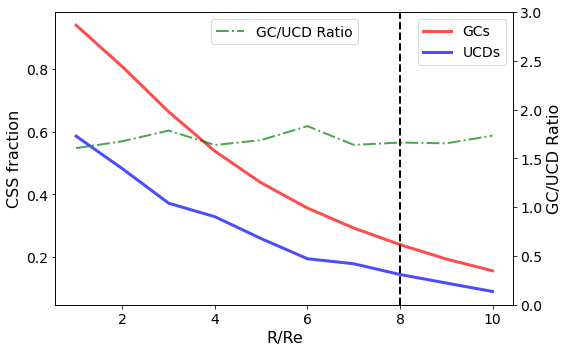

Created figures/intracluster/Coma_GC_UCDs_IC_fraction_with_ratio_all.png


In [33]:
import matplotlib.pyplot as plt

fs = 16
fig, ax = plt.subplots(figsize=(8, 5))

# Plotting the original data for GCs and UCDs
ax.plot(IC_df[IC_df['type']=='ICGC']['Re_mult'], IC_df[IC_df['type']=='ICGC']['frac'], label='GCs', color='red', alpha=0.7, linewidth=3)
ax.plot(IC_df[IC_df['type']=='ICUCD']['Re_mult'], IC_df[IC_df['type']=='ICUCD']['frac'], label='UCDs', color='blue', alpha=0.7, linewidth=3)

# Set labels and formatting for the first y-axis
ax.set_xlabel('R/Re', fontsize=fs)
ax.set_ylabel('CSS fraction', fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-2)
ax.legend(fontsize=fs-2)

# Add a vertical line at x = 8.0
ax.axvline(x=8.0, color='black', linestyle='--', lw=2)

# Create a secondary y-axis that shares the same x-axis
ax2 = ax.twinx()

# Calculate the ratio between GCs and UCDs
gc_values = IC_df[IC_df['type'] == 'ICGC']['frac']
ucd_values = IC_df[IC_df['type'] == 'ICUCD']['frac']

# Make sure they align by using the same 'Re_mult'
re_mult_gc = IC_df[IC_df['type'] == 'ICGC']['Re_mult']
re_mult_ucd = IC_df[IC_df['type'] == 'ICUCD']['Re_mult']

# Interpolate or match the two arrays by common x values
# This assumes the lengths of 'GC' and 'UCD' are aligned and correspond
ratio = gc_values.values / ucd_values.values

# Plot the ratio on the secondary y-axis
ax2.plot(re_mult_gc, ratio, label='GC/UCD Ratio', color='green', alpha=0.7, linewidth=2, linestyle='-.')
ax2.set_ylabel('GC/UCD Ratio', fontsize=fs)
ax2.tick_params(axis='y', labelsize=fs-2)
# Set pixel limits directly
ax2.set_ylim(0, 3)
ax2.legend(fontsize=fs-2, loc='upper center')

# Tight layout and saving
plt.tight_layout()
plt.show()

# Save the figure
path = 'figures/intracluster/'
figname = f'{path}Coma_GC_UCDs_IC_fraction_with_ratio_{idlabel}.png'
fig.savefig(figname, bbox_inches='tight', format='png', dpi=300)
plt.close()
print(f"Created {figname}")


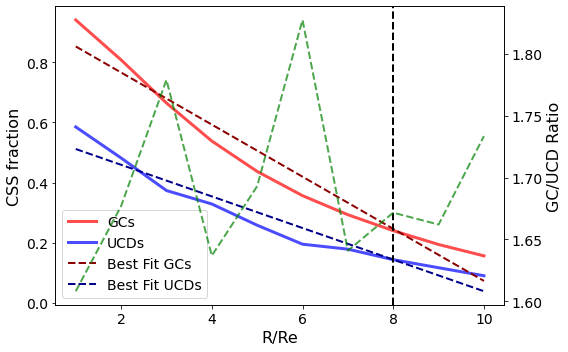

Created figures/intracluster/Coma_GC_UCDs_IC_fraction_with_ratio_and_fit_all.png


In [98]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Clean the data to ensure it's numeric and drop NaN values
ICGC_data = IC_df[IC_df['type'] == 'ICGC'][['Re_mult', 'frac']].dropna()
ICUCD_data = IC_df[IC_df['type'] == 'ICUCD'][['Re_mult', 'frac']].dropna()

# Ensure data is numeric (use errors='coerce' to convert non-numeric values to NaN)
ICGC_data['Re_mult'] = pd.to_numeric(ICGC_data['Re_mult'], errors='coerce')
ICGC_data['frac'] = pd.to_numeric(ICGC_data['frac'], errors='coerce')

ICUCD_data['Re_mult'] = pd.to_numeric(ICUCD_data['Re_mult'], errors='coerce')
ICUCD_data['frac'] = pd.to_numeric(ICUCD_data['frac'], errors='coerce')

# Now that the data is cleaned, extract x and y values for GCs and UCDs
gc_x = ICGC_data['Re_mult']
gc_y = ICGC_data['frac']
ucd_x = ICUCD_data['Re_mult']
ucd_y = ICUCD_data['frac']

# Plot the original data
fs = 16
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(gc_x, gc_y, label='GCs', color='red', alpha=0.7, linewidth=3)
ax.plot(ucd_x, ucd_y, label='UCDs', color='blue', alpha=0.7, linewidth=3)

# Perform linear fits for both GCs and UCDs
gc_fit_coeffs = np.polyfit(gc_x, gc_y, 1)  # Linear fit (degree 1)
gc_fit_line = np.polyval(gc_fit_coeffs, gc_x)

ucd_fit_coeffs = np.polyfit(ucd_x, ucd_y, 1)
ucd_fit_line = np.polyval(ucd_fit_coeffs, ucd_x)

# Plot the best-fit lines
ax.plot(gc_x, gc_fit_line, label='Best Fit GCs', color='darkred', linestyle='--', linewidth=2)
ax.plot(ucd_x, ucd_fit_line, label='Best Fit UCDs', color='darkblue', linestyle='--', linewidth=2)

# Set labels, legend, and formatting
ax.legend(fontsize=fs-2)
ax.set_xlabel('R/Re', fontsize=fs)
ax.set_ylabel('CSS fraction', fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-2)
# Set pixel limits directly
ax2.set_ylim(0, 3)
ax2.legend(fontsize=fs-2, loc='upper center')

# Add vertical line
ax.axvline(x=8.0, color='black', linestyle='--', lw=2)

# Secondary y-axis for ratio
ax2 = ax.twinx()

# Compute the ratio of GCs to UCDs
ratio = gc_y.values / ucd_y.values
ax2.plot(gc_x, ratio, label='GC/UCD Ratio', color='green', alpha=0.7, linewidth=2, linestyle='--')
ax2.set_ylabel('GC/UCD Ratio', fontsize=fs)
ax2.tick_params(axis='y', labelsize=fs-2)

# Tight layout and save
plt.tight_layout()
plt.show()

path = 'figures/intracluster/'
figname = f'{path}Coma_GC_UCDs_IC_fraction_with_ratio_and_fit_{idlabel}.png'
fig.savefig(figname, bbox_inches='tight', format='png', dpi=300)
plt.close()
print(f"Created {figname}")


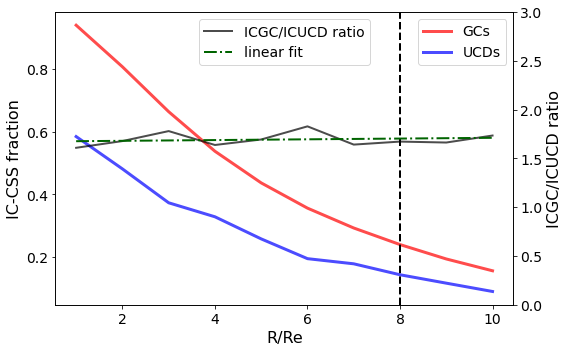

Created figures/intracluster/Coma_GC_UCDs_IC_fraction_all.png


In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Clean the data to ensure it's numeric and drop NaN values
ICGC_data = IC_df[IC_df['type'] == 'ICGC'][['Re_mult', 'frac']].dropna()
ICUCD_data = IC_df[IC_df['type'] == 'ICUCD'][['Re_mult', 'frac']].dropna()

# Ensure data is numeric (use errors='coerce' to convert non-numeric values to NaN)
ICGC_data['Re_mult'] = pd.to_numeric(ICGC_data['Re_mult'], errors='coerce')
ICGC_data['frac'] = pd.to_numeric(ICGC_data['frac'], errors='coerce')

ICUCD_data['Re_mult'] = pd.to_numeric(ICUCD_data['Re_mult'], errors='coerce')
ICUCD_data['frac'] = pd.to_numeric(ICUCD_data['frac'], errors='coerce')

# Now that the data is cleaned, extract x and y values for GCs and UCDs
gc_x = ICGC_data['Re_mult']
gc_y = ICGC_data['frac']
ucd_x = ICUCD_data['Re_mult']
ucd_y = ICUCD_data['frac']

# Plot the original data for GCs and UCDs
fs = 16
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(gc_x, gc_y, label='GCs', color='red', alpha=0.7, linewidth=3)
ax.plot(ucd_x, ucd_y, label='UCDs', color='blue', alpha=0.7, linewidth=3)

# Add legend and labels for the first y-axis
ax.legend(fontsize=fs-2)
ax.set_xlabel('R/Re', fontsize=fs)
ax.set_ylabel('IC-CSS fraction', fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-2)

# Add a vertical line at x = 8.0
ax.axvline(x=8.0, color='black', linestyle='--', lw=2)

# Create a secondary y-axis for the ratio
ax2 = ax.twinx()

# Compute the ratio of GCs to UCDs
ratio = gc_y.values / ucd_y.values
ax2.plot(gc_x, ratio, label='ICGC/ICUCD ratio', color='black', alpha=0.7, linewidth=2, linestyle='-')
ax2.set_ylabel('ICGC/ICUCD ratio', fontsize=fs)
ax2.tick_params(axis='y', labelsize=fs-2)

# Linear fit for the ratio
ratio_fit_coeffs = np.polyfit(gc_x, ratio, 1)  # Linear fit (degree 1)
ratio_fit_line = np.polyval(ratio_fit_coeffs, gc_x)

# Plot the best-fit line for the ratio
ax2.plot(gc_x, ratio_fit_line, label='linear fit', color='darkgreen', linestyle='-.', linewidth=2)
# Set pixel limits directly
ax2.set_ylim(0, 3)
# Add legend for the secondary y-axis
ax2.legend(fontsize=fs-2, loc='upper center')

# Tight layout and save
plt.tight_layout()
plt.show()

# Save the figure
path = 'figures/intracluster/'
figname = f'{path}Coma_GC_UCDs_IC_fraction_{idlabel}.png'
fig.savefig(figname, bbox_inches='tight', format='png', dpi=300)
plt.close()
print(f"Created {figname}")


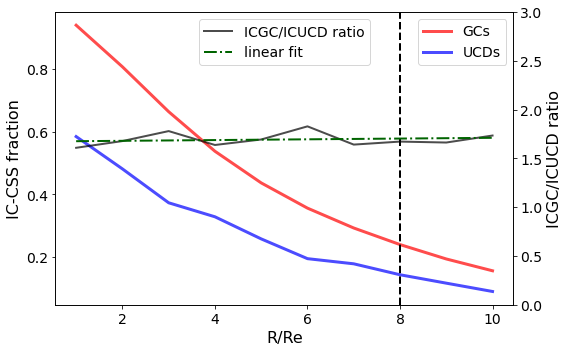

Created Coma_GC_UCDs_IC_fraction_all.png


In [100]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def clean_data(df, type_value, columns):
    """Filter, clean, and return numeric data for the specified type."""
    filtered_data = df[df['type'] == type_value][columns].dropna()
    for column in columns:
        filtered_data[column] = pd.to_numeric(filtered_data[column], errors='coerce')
    return filtered_data.dropna()

def extract_plot_data(data):
    """Extract x and y values for plotting."""
    return data['Re_mult'], data['frac']

def plot_primary_data(ax, x_gc, y_gc, x_ucd, y_ucd, fs):
    """Plot primary data for GCs and UCDs on the main y-axis."""
    ax.plot(x_gc, y_gc, label='GCs', color='red', alpha=0.7, linewidth=3)
    ax.plot(x_ucd, y_ucd, label='UCDs', color='blue', alpha=0.7, linewidth=3)
    ax.legend(fontsize=fs-2)
    ax.set_xlabel('R/Re', fontsize=fs)
    ax.set_ylabel('IC-CSS fraction', fontsize=fs)
    ax.tick_params(axis='both', labelsize=fs-2)
    ax.axvline(x=8.0, color='black', linestyle='--', lw=2)

def compute_and_plot_ratio(ax2, x_gc, y_gc, y_ucd, fs):
    """Compute and plot the ratio of GCs to UCDs on the secondary y-axis."""
    ratio = y_gc.values / y_ucd.values
    ax2.plot(x_gc, ratio, label='ICGC/ICUCD ratio', color='black', alpha=0.7, linewidth=2)
    ax2.set_ylabel('ICGC/ICUCD ratio', fontsize=fs)
    ax2.tick_params(axis='y', labelsize=fs-2)
    
    # Linear fit for the ratio
    ratio_fit_coeffs = np.polyfit(x_gc, ratio, 1)
    ratio_fit_line = np.polyval(ratio_fit_coeffs, x_gc)
    
    # Plot best-fit line for ratio
    ax2.plot(x_gc, ratio_fit_line, label='linear fit', color='darkgreen', linestyle='-.', linewidth=2)
    ax2.set_ylim(0, 3)
    ax2.legend(fontsize=fs-2, loc='upper center')

def save_figure(fig, filename):
    """Save the figure to file."""
    path = 'figures/intracluster/'
    fig.savefig(f'{path}{filename}', bbox_inches='tight', format='png', dpi=300)
    plt.close()
    print(f"Created {filename}")

def do_plot(df):
    # Define font size and initialize figure
    fs = 16
    fig, ax = plt.subplots(figsize=(8, 5))

    # Clean data for GCs and UCDs
    ICGC_data = clean_data(df, 'ICGC', ['Re_mult', 'frac'])
    ICUCD_data = clean_data(df, 'ICUCD', ['Re_mult', 'frac'])

    # Extract plot data
    gc_x, gc_y = extract_plot_data(ICGC_data)
    ucd_x, ucd_y = extract_plot_data(ICUCD_data)

    # Plot primary data and ratio with secondary y-axis
    plot_primary_data(ax, gc_x, gc_y, ucd_x, ucd_y, fs)
    ax2 = ax.twinx()
    compute_and_plot_ratio(ax2, gc_x, gc_y, ucd_y, fs)

    # Show and save the plot
    plt.tight_layout()
    plt.show()
    figname = f'Coma_GC_UCDs_IC_fraction_{idlabel}.png'
    save_figure(fig, figname)

# Plot bright ICGC and ICUCD fractions:
do_plot(IC_df)
# IC_df


### Now look at Sersic and Exponential fits

In [33]:
# ICGC_data = clean_data(ICdf, 'ICGC', ['Re_mult', 'pc'])
IC_df


,type,Re_mult,count,count_err,frac
0,ICGC,1,21466.728,3.404404,0.940368
1,ICGC,2,18436.171,5.889305,0.807612
2,ICGC,3,15159.287,6.815871,0.664065
3,ICGC,4,12283.956,7.180762,0.538109
4,ICGC,5,9970.415,7.094523,0.436763
5,ICGC,6,8136.012,7.012442,0.356405
6,ICGC,7,6685.166,6.504135,0.292849
7,ICGC,8,5477.914,6.114177,0.239965
8,ICGC,9,4426.481,5.518555,0.193906
9,ICGC,10,3568.704,5.321863,0.156330


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import kstest


# define Sérsic profile
def sersic_profile(r, Sigma_e, r_e, n):
    b_n = 2 * n - 1/3
    return Sigma_e * np.exp(np.asarray(-b_n * ((r / r_e)**(1/n) - 1), dtype=float))

# define Exponential profile
def exponential_profile(r, Sigma_0, r_s):
    return Sigma_0 * np.exp(np.asarray(-r / r_s, dtype=float))


def plot_fits(x, y_data, y_err, subplot_idx, xlabel, ylabel, data_label, sersic_label, exp_label, title, 
              data_color, sersic_style, exp_style, mrk_fmt):
    """
    Function to plot data with Sérsic and Exponential fits.

    Parameters:
    - x: array-like, independent variable (e.g., R_e values)
    - y_data: array-like, dependent variable (e.g., ICGC% or ICUCD% data)
    - subplot_idx: tuple (rows, cols, index) for plt.subplot
    - xlabel: str, label for the x-axis
    - ylabel: str, label for the y-axis
    - data_label: str, legend label for the data points
    - sersic_label: str, legend label for the Sérsic fit
    - exp_label: str, legend label for the Exponential fit
    - title: str, title of the subplot
    - data_color: str, color of the data points
    - sersic_style: str, line style for the Sérsic fit
    - exp_style: str, line style for the Exponential fit
    """
    fs = 16
    # Generate smooth x-values for plotting
    x_smooth = np.linspace(x.min(), x.max(), 500)
    
    # Fit Sérsic model to ICGC%
    popt_sersic, _ = curve_fit(sersic_profile, x, y_data, p0=[1, 2, 1])
    # Fit Exponential model to ICGC%
    popt_exp, _ = curve_fit(exponential_profile, x, y_data, p0=[100, 2])

    # Sérsic and Exponential fits for plotting
    y_sersic_fit = sersic_profile(x_smooth, *popt_sersic)
    y_exp_fit = exponential_profile(x_smooth, *popt_exp)
    
    # Calculate Sérsic and Exponential fits at original R_e points 
    y_sersic_at_data = sersic_profile(x, *popt_sersic)
    y_exp_at_data = exponential_profile(x, *popt_exp)
    
    # Metrics 
    ssr_sersic, r2_sersic, aic_sersic = calculate_metrics(x, y_data, y_sersic_at_data, 3)
    ssr_exp, r2_exp, aic_exp = calculate_metrics(x, y_data, y_exp_at_data, 2)
#     ks_stat, ks_pvalue = kstest(y_data, sersic_profile, *popt_sersic)

    # Print fitted parameters
    print(f"{title} Parameters and Metrics")
    print(f"{sersic_label}: Σ_e={popt_sersic[0]:.2f}, R_e={popt_sersic[1]:.2f}, n={popt_sersic[2]:.2f}")
    print(f"Sérsic metric: SSR={ssr_sersic:.2f}, R^2={r2_sersic:.2f}, AIC={aic_sersic:.2f}")
    print(f"{exp_label}: Σ_0={popt_exp[0]:.2f}, R_s={popt_exp[1]:.2f}")
    print(f"Exponential metric: SSR={ssr_exp:.2f}, R^2={r2_exp:.2f}, AIC={aic_exp:.2f}")
    print()
#     print(f"KS p-value for GCs vs Sersic profile: {ks_pvalue}")


    plt.subplot(*subplot_idx)
    plt.axvline(x=8.0, color='black', linestyle='-.', lw=3)
    plt.errorbar(x, y_data, y_err, fmt=mrk_fmt, color=data_color, label=data_label, zorder=5, lw=2, ms=10)
    plt.plot(x_smooth, y_sersic_fit, sersic_style, color=data_color, label=sersic_label, lw=2)
#     plt.plot(x_smooth, y_exp_fit, exp_style, label=exp_label)
    plt.xlabel(xlabel, fontsize=fs)
    plt.ylabel(ylabel, fontsize=fs)
    plt.tick_params(axis='both', labelsize=fs-2)
#     plt.title(title)
    plt.legend(fontsize=fs-2, loc='upper center')
    
    print()
    
    return popt_sersic, popt_exp
    
def calculate_metrics(x, y_data, y_model, num_params):
    """
    Calculate metrics to assess fit quality.
    
    Parameters:
    - x: array-like, independent variable
    - y_data: array-like, observed data
    - y_model: array-like, model predictions
    - num_params: int, number of parameters in the model

    Returns:
    - SSR: Sum of Squared Residuals
    - R^2: Coefficient of determination
    - AIC: Akaike Information Criterion
    """
    residuals = y_data - y_model
    ssr = np.sum(residuals**2)  # Sum of squared residuals
    sst = np.sum((y_data - np.mean(y_data))**2)  # Total sum of squares
    r_squared = 1 - ssr / sst  # R-squared
    n = len(y_data)
    aic = n * np.log(ssr / n) + 2 * num_params  # AIC formula
    
    return ssr, r_squared, aic



### Assessing Fit Quality

To determine which model (Sérsic or Exponential) provides a better fit, we use statistical metrics:

- Sum of Squared Residuals (SSR): Measures the total squared difference between the observed data and model predictions. **Lower values indicate a better fit**.
- R-squared (R^2^): Proportion of variance explained by the model. **Closer to 1 is better**.
- Akaike Information Criterion (AIC) or Bayesian Information Criterion (BIC): Penalize models for complexity (e.g., more parameters in the Sérsic model). **Lower values indicate a better tradeoff between fit quality and complexity**.


ICGC Fit Parameters and Metrics
Sérsic Fit (ICGC): Σ_e=0.26, R_e=7.58, n=0.89
Sérsic metric: SSR=0.00, R^2=1.00, AIC=-96.19
Exponential Fit (ICGC): Σ_0=1.17, R_s=5.09
Exponential metric: SSR=0.00, R^2=1.00, AIC=-86.87


ICUCD Fit Parameters and Metrics
Sérsic Fit (ICUCD): Σ_e=0.13, R_e=8.31, n=1.02
Sérsic metric: SSR=0.00, R^2=1.00, AIC=-89.31
Exponential Fit (ICUCD): Σ_0=0.72, R_s=4.88
Exponential metric: SSR=0.00, R^2=1.00, AIC=-91.21




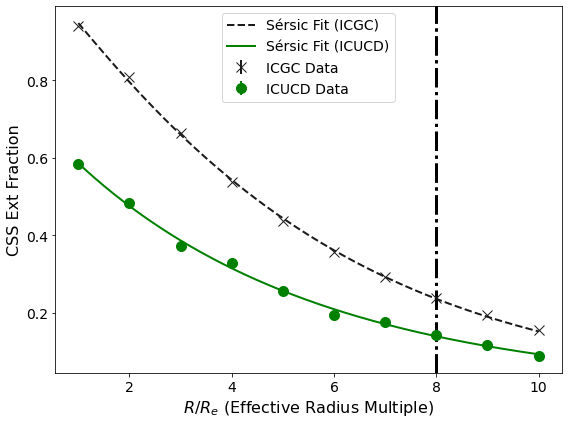

Created figures/intracluster/Coma_GC_UCDs_IC_Sersic_all.png


In [35]:

# Extract data
GC_df = IC_df[IC_df['type']=='ICGC']
UCD_df = IC_df[IC_df['type']=='ICUCD']

R_e = GC_df['Re_mult'].to_numpy()  # Effective radius multiples

ICGC_frac = GC_df['frac'].to_numpy()  # ICGC %
ICUCD_frac = UCD_df['frac'].to_numpy()  # ICUCD %

ICGC_count = GC_df['count'].to_numpy()  # ICGC count
ICUCD_count = UCD_df['count'].to_numpy()  # ICUCD count 

ICGC_err = GC_df['count_err'].to_numpy()/total_gcs  # ICGC count
ICUCD_err = UCD_df['count_err'].to_numpy()/total_ucds  # ICUCD count 

print()

# Plot results
plt.figure(figsize=(8, 6))

# Plot ICGC%
gc_sersic, gc_exp = plot_fits(x=R_e, y_data=ICGC_frac, y_err=ICGC_err, subplot_idx=(1, 1, 1),
                              xlabel='$R/R_e$ (Effective Radius Multiple)', ylabel='ICGC', data_label='ICGC Data',
                              sersic_label='Sérsic Fit (ICGC)', exp_label='Exponential Fit (ICGC)', 
                              title='ICGC Fit', data_color='0.1', sersic_style='--', exp_style=':', mrk_fmt='x'
                             )

# Plot ICUCD%
ucd_sersic, ucd_exp = plot_fits(x=R_e, y_data=ICUCD_frac, y_err=ICUCD_err, subplot_idx=(1, 1, 1),
                                xlabel='$R/R_e$ (Effective Radius Multiple)', ylabel='CSS Ext Fraction', data_label='ICUCD Data',
                                sersic_label='Sérsic Fit (ICUCD)', exp_label='Exponential Fit (ICUCD)', 
                                title='ICUCD Fit', data_color='green', sersic_style='-', exp_style=':', mrk_fmt='o'
                               )


# # Plot ICGC count
# plot_fits(x=R_e, y_data=ICGC_count, subplot_idx=(1, 2, 1),
#           xlabel='$R_e$ (Effective Radius Multiple)', ylabel='ICGC count', data_label='ICGC count Data', 
#           sersic_label='Sérsic Fit (ICGC count)', exp_label='Exponential Fit (ICGC count)', 
#           title='ICGC count Fit', data_color='blue', sersic_style='b--', exp_style='b:'
#          )

# # Plot ICUCD count
# plot_fits(x=R_e, y_data=ICUCD_count, subplot_idx=(1, 2, 2),
#           xlabel='$R_e$ (Effective Radius Multiple)', ylabel='ICUCD count', data_label='ICUCD count Data', 
#           sersic_label='Sérsic Fit (ICUCD count)', exp_label='Exponential Fit (ICUCD count)', 
#           title='ICUCD count Fit', data_color='green', sersic_style='g--', exp_style='g:'
#          )

plt.tight_layout()

# Save the figure
path = 'figures/intracluster/'
figname = f'{path}Coma_GC_UCDs_IC_Sersic_{idlabel}.png'
plt.savefig(figname, bbox_inches='tight', format='png', dpi=300)

plt.show()
plt.close()
print(f"Created {figname}")



\begin{deluxetable}{cccc}
\centering
\label{tab:ICCSS_sersic}
\tablecaption{Best parameters for S\'{e}rsic fit of GCs and UCDs shown in \cref{fig:ICCSS_comparison} for central region of Coma cluster. Units of $R_e$ are in multiples of host galaxy effective radius.}
\tablehead{
    \colhead{Param} & \colhead{GC Value} & \colhead{UCD Value} & \colhead{Description}
}
\startdata
    $n$ & 0.89 & 1.02 & S\'{e}rsic index\\
    $R_e$ & 7.58 & 8.32 & S\'{e}rsic effective radius \\
    $\Sigma_e$ & 0.26 & 0.13 & Surface density at $R_e$\\
\enddata
\end{deluxetable}

In [58]:
print(f'% table created in {notebook_name}')
print('\\begin{deluxetable}{cccc}')
print('\\label{tab:ICCSS_sersic}')
print('\\tablecaption{Best parameters for S\'{e}rsic fit of GCs and UCDs shown in \\cref{fig:ICCSS_comparison} for central region of Coma cluster. Units of $R_e$ are in multiples of host galaxy effective radius.}')
print('\\tablehead{\n\t\\colhead{Param} & \\colhead{GC Value} & \\colhead{UCD Value} & \\colhead{Description}\n}')
print('\\startdata')
print(f'\t$n$ & {gc_sersic[2]:.2f} & {ucd_sersic[2]:.2f} & S\\\'{{e}}rsic index \\\\')
print(f'\t$R_e$ & {gc_sersic[1]:.2f} & {ucd_sersic[1]:.2f} & S\\\'{{e}}rsic effective radius \\\\')
print(f'\t$\Sigma_e$ & {gc_sersic[0]:.2f} & {ucd_sersic[0]:.2f} & Surface density at $R_e$ \\\\')
print('\\enddata')
print('\\end{deluxetable}')

% table created in Coma_UCDs_Position.ipynb
\begin{deluxetable}{cccc}
\label{tab:ICCSS_sersic}
\tablecaption{Best parameters for S'{e}rsic fit of GCs and UCDs shown in \cref{fig:ICCSS_comparison} for central region of Coma cluster. Units of $R_e$ are in multiples of host galaxy effective radius.}
\tablehead{
	\colhead{Param} & \colhead{GC Value} & \colhead{UCD Value} & \colhead{Description}
}
\startdata
	$n$ & 0.89 & 1.02 & S\'{e}rsic index \\
	$R_e$ & 7.58 & 8.31 & S\'{e}rsic effective radius \\
	$\Sigma_e$ & 0.26 & 0.13 & Surface density at $R_e$ \\
\enddata
\end{deluxetable}


### Sersic parameters

Σ_e: Surface density at the object effective radius (r_e).

- This gives the scale of the profile at r_e.

r_e: Effective radius, where half the integrated profile lies.

- Determines how stretched or compact the distribution is.

n: Sérsic index, which controls the shape of the profile.

- n=1: Exponential profile (common for disk-like systems).
- n>1: Sharper central peak and extended tails (e.g., bulges or elliptical distributions).

### Exponential parameters

For exponential fit:

Σ_0: Central surface density (at r=0).

- Represents the highest value of the profile.

r_s: Scale radius.

- Determines how quickly the profile falls off with radius.

### Comparing Observed Distributions: GCs vs UCDs

Now I want to test whether the radial distributions (or any other property like magnitude) of intracluster GCs and UCDs are statistically different:
 - Two-sample KS test: Tests whether the two observed distributions (e.g., radial distances of GCs and UCDs) are drawn from the same parent distribution.
 - Two-sample AD test: More sensitive to differences in the tails of the distributions.
 

In [59]:
from scipy.stats import ks_2samp, anderson_ksamp

# Data: radial distances of GCs and UCDs
ks_stat, ks_pvalue = ks_2samp(ICGC_frac, ICUCD_frac)
ad_stat, ad_crit_values, ad_sig_level = anderson_ksamp([ICGC_frac, ICUCD_frac])

print(f"KS p-value: {ks_pvalue}")
print(f"AD statistic: {ad_stat}")


KS p-value: 0.7869297884777761
AD statistic: 0.9945505510346423


### Calculate 2-point Correlation function

In [31]:
np.max(gcs_df['x_wcs'].values)


195.28862

In [61]:
from astropy.coordinates import SkyCoord
# from astropy.cosmology import Planck18 as cosmo
import numpy as np
from numpy.random import uniform
import matplotlib.pyplot as plt
import astropy.units as u
from tqdm import tqdm  # For progress bar

# Set desired limits in WCS (RA, Dec)
ra_min, ra_max = 195.30, 194.72  # RA limits in degrees
dec_min, dec_max = 27.795, 28.20  # Dec limits in degrees
cluster_redshift = 0.026


def get_angular_sep(d: float, D: float):
    """
    Get the angular separation in arcsec
    
    Parameters:
    d: spatial distance in parsecs
    D: radial distance to object, also in parsecs
    
    Returns: 
    angular seperation in arcseconds
    """
    return (d/D)*(180/np.pi)*3600

def get_spatial_dist(theta: float, D: float,):
    """
    Get the spatial distance in parsecs
    
    Parameters:
    Theta: anglular seperation in arcseconds
    D: radial distance to object, in parsecs
    
    Returns:
    spatial distance in parsecs
    """
    return (theta/3600)*(np.pi/180)*D

def get_physical_separations(gal_coords, coords, threshold_kpc=100):
    """
    Calculate the physical separations between galaxy coordinates and another set of coordinates.

    This function computes the physical separations between a galaxy's coordinates
    (`gal_coords`) and another set of coordinates (`coords`). It performs an
    angular separation calculation, converts these separations to kpc, and
    filters out separations exceeding the specified threshold in kpc.

    :param gal_coords: Galaxy coordinates.
    :type gal_coords: SkyCoord
    :param coords: Coordinates of the target points to measure separations from the galaxy.
    :type coords: SkyCoord
    :param threshold_kpc: Maximum separation in kiloparsecs for the physical distance
                          to be included in the output, defaults to 100 kpc.
    :type threshold_kpc: float, optional
    :return: Physical separations in kiloparsecs that are below the specified threshold.
    :rtype: ndarray
    """

    # Calculate physical distances
    separations = gal_coords.separation(coords).to(u.arcsec).value
    physical_separations = get_spatial_dist(separations, 100e3) # * convert to kpc seperations
    # Apply the radial cut
    filtered_physical_separations = physical_separations[physical_separations < threshold_kpc]
#     print(len(physical_separations), len(filtered_physical_separations))
    return filtered_physical_separations

def get_distance_bins(start=0, end=200, number=8):
    # Define distance bins (e.g., 10-500 kpc in 10 kpc steps)
    bins = np.linspace(start, end, number)  # kpc
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    return bins, bin_centers

def get_hist_counts(physical_separations, bins):
    # Calculate distances between CSS and a galaxy
    distances = physical_separations  # Ensure in kpc
    hist_counts, _ = np.histogram(distances, bins=bins)
    return hist_counts

# def generate_random_pos(coords):
#     # Generate random CSS positions
#     n_random = len(coords)
#     random_ra = uniform(ra_min, ra_max, n_random)
#     random_dec = uniform(dec_min, dec_max, n_random)
#     random_coords = SkyCoord(ra=random_ra * u.deg, dec=random_dec * u.deg, frame='icrs')
#     return random_coords

def generate_random_pos(coords, galaxy_coord, min_radius_kpc=1, max_radius_kpc=100, n_random=None, galaxy_distance_mpc=100):
    """
    Generate random positions based on radial distance from a galaxy.
    
    Parameters:
    - coords: Original SkyCoord array of UCDs/GCs.
    - galaxy_coord: SkyCoord object for the central galaxy.
    - min_radius_kpc: Minimum radial distance from the galaxy (kpc).
    - max_radius_kpc: Maximum radial distance from the galaxy (kpc).
    - n_random: Number of random positions to generate.
    - galaxy_distance_mpc: Distance to the galaxy in Mpc (for angular scaling).
    
    Returns:
    - random_coords: SkyCoord array of random positions.
    """

    # set default number of random points to generate if n_random not included
    if n_random is None:
        n_random = len(coords)

    # Convert radial distances from kpc to degrees
    kpc_to_deg = (1 / galaxy_distance_mpc) * (180 / np.pi) * (1/1000)  # Conversion factor
    min_radius_deg = min_radius_kpc * kpc_to_deg
    max_radius_deg = max_radius_kpc * kpc_to_deg
    
    # Generate random radii uniformly in area (r^2 distribution)
    random_radii_deg = np.sqrt(np.random.uniform(min_radius_deg**2, max_radius_deg**2, n_random))

    # Generate random angles (theta) uniformly in [0, 2*pi]
    random_theta = np.random.uniform(0, 2 * np.pi, n_random)

    # Convert polar to Cartesian offsets (delta RA, delta DEC)
    delta_ra = random_radii_deg * np.cos(random_theta) / np.cos(galaxy_coord.dec.radian)
    delta_dec = random_radii_deg * np.sin(random_theta)

    # Calculate random RA and DEC
    random_ra = galaxy_coord.ra.deg + delta_ra
    random_dec = galaxy_coord.dec.deg + delta_dec

    # Create random SkyCoord positions
    random_coords = SkyCoord(ra=random_ra * u.deg, dec=random_dec * u.deg, frame='icrs')
    return random_coords


def get_2_pcf(dd_counts, rr_counts, coords, random_coords):
    """
    Compute the two-point correlation function (2PCF) for a given dataset.

    This function computes the 2-point correlation function by normalizing the
    random pair counts (RR) to match the scale of the observed pair counts
    (DD) based on the ratio of the length of the original coordinates to the
    corresponding random coordinates. The output represents the correlation
    function highlighting the clustering characteristics present in the dataset.

    :param dd_counts: Observed pair counts within the dataset
    :type dd_counts: float or numpy.ndarray
    :param rr_counts: Pair counts derived from the random distribution
    :type rr_counts: float or numpy.ndarray
    :param coords: Array of original coordinates for the observed data
    :type coords: numpy.ndarray
    :param random_coords: Array of randomly-generated coordinates for comparison
    :type random_coords: numpy.ndarray
    :return: Two-point correlation function (2PCF) values calculated from the
        observed pair counts and normalized random pair counts
    :rtype: numpy.ndarray
    """

    # Normalize RR to match the total number of pairs in DD
    rr_counts = rr_counts * (len(coords) / len(random_coords))
    # Compute 2PCF
    xi_r = (dd_counts / rr_counts) - 1
    return xi_r


def get_poisson_errors(dd_r, rr_r):
    """
    Calculate Poisson errors for given pair counts.

    Poisson errors are used to estimate the uncertainty in measurements based
    on the direct pair counts for a dataset. This function computes the errors
    using Poisson statistics, given the pair counts for data.

    :param dd_r: Pair count for data-data region.
    :type dd_r: float
    :param rr_r: Pair count for random-random region.
    :type rr_r: float
    :return: The calculated Poisson error for the given pair counts.
    :rtype: float
    """

    # Poisson errors estimate uncertainty based on the pair counts directly.
    sigma_eps_r = np.sqrt((1/dd_r)+(1/rr_r))
    return sigma_eps_r


In [42]:
# %% Imports
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from tqdm import tqdm  # For progress bar
from numpy.random import uniform
from scipy.stats import gaussian_kde

# %% Constants
KPC_TO_MPC = 1 / 1000  # Conversion factor
DEG_TO_ARCSEC = 3600

# Coordinate limits in WCS (RA, Dec) for the region of interest
RA_MIN, RA_MAX = 195.30, 194.72  # RA limits in degrees
DEC_MIN, DEC_MAX = 27.795, 28.20  # Dec limits in degrees
CLUSTER_REDSHIFT = 0.026


# %% Functions
def calculate_angular_separation(d: float, D: float) -> float:
    """
    Calculate the angular separation in arcseconds for a given spatial distance and radial distance.
    """
    return (d / D) * (180 / np.pi) * DEG_TO_ARCSEC


def calculate_spatial_distance(theta: float, D: float) -> float:
    """
    Calculate the spatial distance in parsecs for a given angular separation and radial distance.
    """
    return (theta / DEG_TO_ARCSEC) * (np.pi / 180) * D


def convert_kpc_to_deg(radius_kpc: float, galaxy_distance_mpc: float) -> float:
    """
    Convert a radial distance from kpc to degrees given the galaxy distance in Mpc.
    """
    return radius_kpc * (1 / galaxy_distance_mpc) * (180 / np.pi) * KPC_TO_MPC


def calculate_physical_separations(
        galaxy_coords: SkyCoord,
        target_coords: SkyCoord,
        threshold_kpc: float = 100
) -> np.ndarray:
    """
    Calculate physical separations (in kpc) between a central galaxy and other coordinates,
    and filter based on a threshold.
    """
    separations_arcsec = galaxy_coords.separation(target_coords).to(u.arcsec).value
    physical_separations = calculate_spatial_distance(separations_arcsec, 100e3)  # Convert to kpc
    return physical_separations[physical_separations < threshold_kpc]


def generate_random_positions(
        coords: SkyCoord,
        central_galaxy_coord: SkyCoord,
        min_radius_kpc: float = 1,
        max_radius_kpc: float = 100,
        n_random: int = None,
        galaxy_distance_mpc: float = 100
) -> SkyCoord:
    """
    Generate random SkyCoord positions within a specified radial range (in kpc) around a galaxy.
    """

    n_random = n_random or len(coords)
    min_radius_deg = convert_kpc_to_deg(min_radius_kpc, galaxy_distance_mpc)
    max_radius_deg = convert_kpc_to_deg(max_radius_kpc, galaxy_distance_mpc)

    random_radii_deg = np.sqrt(np.random.uniform(min_radius_deg ** 2, max_radius_deg ** 2, n_random))
    random_theta = np.random.uniform(0, 2 * np.pi, n_random)

    delta_ra = random_radii_deg * np.cos(random_theta) / np.cos(central_galaxy_coord.dec.radian)
    delta_dec = random_radii_deg * np.sin(random_theta)

    random_ra = central_galaxy_coord.ra.deg + delta_ra
    random_dec = central_galaxy_coord.dec.deg + delta_dec
    return SkyCoord(ra=random_ra * u.deg, dec=random_dec * u.deg, frame='icrs')


############################## Using this for final calcs #####################################
def bootstrap_kde(separations, kde_points, bandwidth, n_bootstrap=100):
    """
    Compute bootstrap confidence intervals for a KDE.

    Parameters:
        separations (array): Array of distances to analyze.
        kde_points (array): Points at which to evaluate the KDE.
        bandwidth (float): Bandwidth for the KDE.
        n_bootstrap (int): Number of bootstrap samples.

    Returns:
        mean_kde (array): Mean KDE values.
        ci_lower (array): Lower bound of confidence intervals.
        ci_upper (array): Upper bound of confidence intervals.
    """
    bootstrap_estimates = []

    for _ in range(n_bootstrap):
        # Resample separations with replacement
        resampled_separations = np.random.choice(separations, size=len(separations), replace=True)
#         print(resampled_separations)  # Check (num_points, num_dimensions)
        # Calculate KDE for resampled data
        kde = gaussian_kde(resampled_separations, bw_method=bandwidth) # 
        bootstrap_estimates.append(kde(kde_points))

    # Convert list to array for easier calculations
    bootstrap_estimates = np.array(bootstrap_estimates)

    # Calculate mean and confidence intervals
    mean_kde = np.mean(bootstrap_estimates, axis=0)
    ci_lower = np.percentile(bootstrap_estimates, 16, axis=0)
    ci_upper = np.percentile(bootstrap_estimates, 84, axis=0)

    return mean_kde, ci_lower, ci_upper


In [43]:
calculate_spatial_distance(1980, 100e3)  # gives spatial distance (in pc) for 100 arcsec at 100 Mpc (should be ~50,000 pc or ~ 50kpc)


959.9310885968814

In [44]:
############################## Using this for final calcs #####################################
def get_gal_coords(gal_name):
    """
    Get Galaxy Celestial coordinates

    This function retrieves the celestial coordinates of a galaxy in the sky based
    on its name. It fetches the galaxy's Right Ascension (RA) and Declination (Dec)
    from a predefined dataset and calculates the coordinates using an astropy
    SkyCoord object in the ICRS frame.

    """

    i = galaxies['galname'].index(gal_name)
#     print(galaxies['galname'][i], galaxies['x_wcs'][i], galaxies['y_wcs'][i] )
#     print(ra_min, ra_max, dec_min, dec_max)

    galaxy_ra = galaxies['x_wcs'][i]
    galaxy_dec = galaxies['y_wcs'][i] 

    # Get galaxy coords and UCD / GC positions from dataframe
    galaxy_coords = SkyCoord(ra=galaxy_ra * u.deg, dec=galaxy_dec * u.deg, frame='icrs')
    return galaxy_coords

def get_galaxy_2pcf_dd(gal_name, start, end, number):
    """
    Calculate the 2-point correlation function

    Calculate the 2-point correlation function (pair counting histogram) for the
    specified galaxy using the galaxy's coordinates and distances to UCDs and GCs.

    This function computes the distances between a specified galaxy and two sets
    of point sources, UCDs (Ultracompact Dwarfs) and GCs (Globular Clusters),
    to create histograms of pair separations. Distances are computed up to a
    given threshold in kiloparsecs.

    """

    # Get galaxy coords and UCD / GC positions from dataframe
    galaxy_coords = get_gal_coords(gal_name)
    ucd_coords = SkyCoord(ra=ucd_sample_df['x_wcs'].values * u.deg, dec=ucd_sample_df['y_wcs'].values * u.deg, frame='icrs')
    gcs_coords = SkyCoord(ra=gcs_sample_df['x_wcs'].values * u.deg, dec=gcs_sample_df['y_wcs'].values * u.deg, frame='icrs')

    # Calculate physical distances
    physical_separations_ucd = calculate_physical_separations(galaxy_coords, ucd_coords, threshold_kpc=end)
    physical_separations_gcs = calculate_physical_separations(galaxy_coords, gcs_coords, threshold_kpc=end)

    # Define distance bins (e.g., 10-500 kpc in 10 kpc steps)
    bins, bin_centers = get_distance_bins(start, end, number)
    
    # Histogram distances between CSS and a galaxy
    dd_counts_ucd = get_hist_counts(physical_separations_ucd, bins)
    dd_counts_gcs = get_hist_counts(physical_separations_gcs, bins)

    return galaxy_coords, bins, bin_centers, ucd_coords, gcs_coords, dd_counts_ucd, dd_counts_gcs
    

def get_galaxy_2pcf_rr(galaxy_coords, end, bins, ucd_coords, gcs_coords, n_filt_ucd, n_filt_gcs):
    """
    Calculates the two-point cross-correlation function random sample counts

    Calculates the two-point cross-correlation function of CSS populations relative
    to a galaxy by generating random positions for UCDs and GCs, measuring their
    physical separations from the galaxy, and binning these separations. The function
    returns the histogram counts of random separations for UCDs and GCs as well as
    the random coordinates generated for each population.

    """

    # Generate random CSS positions 
    random_ucd_coords = generate_random_positions(ucd_coords, galaxy_coords, min_radius_kpc=0, max_radius_kpc=end, n_random=n_filt_ucd)
    random_gcs_coords = generate_random_positions(gcs_coords, galaxy_coords, min_radius_kpc=0, max_radius_kpc=end, n_random=n_filt_gcs)

    # Calculate random distances
    random_separations_ucd = calculate_physical_separations(galaxy_coords, random_ucd_coords, threshold_kpc=end)
    random_separations_gcs = calculate_physical_separations(galaxy_coords, random_gcs_coords, threshold_kpc=end)

    # Histogram random distances between CSS and a galaxy
    rr_counts_ucd = get_hist_counts(random_separations_ucd, bins)
    rr_counts_gcs = get_hist_counts(random_separations_gcs, bins)
    
    return rr_counts_ucd, rr_counts_gcs, random_ucd_coords, random_gcs_coords 


def get_galaxy_2pcf_dd_kde(gal_name, start, end, number, bandwidth=0.1):
    """
    Calculate the 2-point correlation function with KDE smoothing.

    Calculates the 2-point correlation function (pair counting KDE) for the
    specified galaxy using the galaxy's coordinates and distances to UCDs and GCs.
    """

    # Get galaxy coords and UCD / GC positions from dataframe
    galaxy_coords = get_gal_coords(gal_name)
    ucd_coords = SkyCoord(ra=ucd_sample_df['x_wcs'].values * u.deg, dec=ucd_sample_df['y_wcs'].values * u.deg, frame='icrs')
    gcs_coords = SkyCoord(ra=gcs_sample_df['x_wcs'].values * u.deg, dec=gcs_sample_df['y_wcs'].values * u.deg, frame='icrs')

    # Calculate physical distances
    physical_separations_ucd = calculate_physical_separations(galaxy_coords, ucd_coords, threshold_kpc=end)
    physical_separations_gcs = calculate_physical_separations(galaxy_coords, gcs_coords, threshold_kpc=end)

    # Apply KDE to smooth pair counts
    kde_ucd = gaussian_kde(physical_separations_ucd, bw_method=bandwidth)
    kde_gcs = gaussian_kde(physical_separations_gcs, bw_method=bandwidth)

    # Define evaluation points for KDE
    kde_points = np.linspace(start, end, number)
    kde_values_ucd = kde_ucd(kde_points)
    kde_values_gcs = kde_gcs(kde_points)

    return galaxy_coords, kde_points, kde_values_ucd, kde_values_gcs

####################### Added to give uncertainty on sample count ############################
def bootstrap_ucd_count(ucd_separations, threshold_kpc, n_bootstrap=1000, ci=68):
    """
    Perform bootstrap resampling on UCD count, considering only UCDs within a physical threshold.
    
    Parameters:
    - ucd_separations: array-like, physical separations of UCDs
    - threshold_kpc: float, maximum allowed separation
    - n_bootstrap: int, number of bootstrap resamples
    - ci: float, confidence interval percentage (default is 68%)

    Returns:
    - mean_count: float, mean number of UCDs in bootstrap samples
    - lower_ci: float, lower bound of the confidence interval
    - upper_ci: float, upper bound of the confidence interval
    """
    bootstrap_counts = []

    for _ in range(n_bootstrap):
        # Resample with replacement
        resampled_separations = np.random.choice(ucd_separations, size=len(ucd_separations), replace=True)

        # Count how many remain within the threshold
        count_within_threshold = np.sum(resampled_separations <= threshold_kpc)
        bootstrap_counts.append(count_within_threshold)

    mean_count = np.mean(bootstrap_counts)
    lower_ci, upper_ci = np.percentile(bootstrap_counts, [(100 - ci) / 2, 100 - (100 - ci) / 2])

    return mean_count, lower_ci, upper_ci

############################## Using this for final calcs #####################################
def get_galaxy_2pcf_dd_kde_bootstrap(gal_name, start, end, number, bandwidth=0.1, bootstrap=500):
    """
    Calculate the 2-point correlation function with KDE smoothing.

    Calculates the 2-point correlation function (pair counting KDE) for the
    specified galaxy using the galaxy's coordinates and distances to UCDs and GCs.
    """
    global UCD_COUNT
    global UCD_UNCERTAINTY
    global GC_COUNT # added GC globals and calcs here for LSB version
    global GC_UNCERTAINTY
    
    # Get galaxy coords and UCD / GC positions from dataframe
    galaxy_coords = get_gal_coords(gal_name)
    ucd_coords = SkyCoord(ra=ucd_sample_df['x_wcs'].values * u.deg, dec=ucd_sample_df['y_wcs'].values * u.deg, frame='icrs')
    gcs_coords = SkyCoord(ra=gcs_sample_df['x_wcs'].values * u.deg, dec=gcs_sample_df['y_wcs'].values * u.deg, frame='icrs')

    # Calculate physical distances
    physical_separations_ucd = calculate_physical_separations(galaxy_coords, ucd_coords, threshold_kpc=end)
    physical_separations_gcs = calculate_physical_separations(galaxy_coords, gcs_coords, threshold_kpc=end)
    ucds_in_sample = len(physical_separations_ucd)
    gcs_in_sample = len(physical_separations_gcs)

    # Perform bootstrap resampling on UCD count
#     mean_ucd_count, lower_ucd, upper_ucd = bootstrap_ucd_count(
#         physical_separations_ucd, threshold_kpc=end, n_bootstrap=1000
#     )
#     print(f'Gal: {gal_name}, UCDs in threshold: {ucds_in_sample} (± {mean_ucd_count - lower_ucd}, {upper_ucd - mean_ucd_count})')
    ucds_uncertainty = np.sqrt(ucds_in_sample)
    print(f'UCDs in threshold: {ucds_in_sample} ± {ucds_uncertainty:3.1f}')
    UCD_COUNT = ucds_in_sample
    UCD_UNCERTAINTY = ucds_uncertainty
#     print(f'Gal: {gal_name}, UCDs in threshold:{ucds_in_sample}')
    gcs_uncertainty = np.sqrt(gcs_in_sample)
    print(f'GCs in threshold: {gcs_in_sample} ± {gcs_uncertainty:3.1f}')
    GC_COUNT = gcs_in_sample
    GC_UNCERTAINTY = gcs_uncertainty

    # Apply KDE to smooth pair counts
    kde_ucd = gaussian_kde(physical_separations_ucd, bw_method=bandwidth)
    kde_gcs = gaussian_kde(physical_separations_gcs, bw_method=bandwidth)

    # Define evaluation points for KDE
    kde_points = np.linspace(start, end, number)
    kde_values_ucd = kde_ucd(kde_points)
    kde_values_gcs = kde_gcs(kde_points)
    
    # Perform bootstrap for UCD separations
    mean_kde_ucd, ci_lower_ucd, ci_upper_ucd = bootstrap_kde(
        separations=physical_separations_ucd, kde_points=kde_points, bandwidth=bandwidth, n_bootstrap=bootstrap
    )

    # Perform bootstrap for GCs
    mean_kde_gcs, ci_lower_gcs, ci_upper_gcs = bootstrap_kde(
        separations=physical_separations_gcs, kde_points=kde_points, bandwidth=bandwidth, n_bootstrap=bootstrap
    )

    return galaxy_coords, ucd_coords, gcs_coords, kde_points, mean_kde_ucd, ci_lower_ucd, ci_upper_ucd, mean_kde_gcs, ci_lower_gcs, ci_upper_gcs, ucds_in_sample, ucds_uncertainty, gcs_in_sample, gcs_uncertainty


############################## Using this for final calcs #####################################
def get_galaxy_2pcf_rr_kde(galaxy_coords, end, kde_points, ucd_coords, gcs_coords, n_filt_ucd, n_filt_gcs, bandwidth=0.1):
    """
    Calculate the 2-point correlation function for random sample counts with KDE smoothing.
    """

    # Generate random positions
    random_ucd_coords = generate_random_positions(ucd_coords, galaxy_coords, min_radius_kpc=0, max_radius_kpc=end, n_random=n_filt_ucd)
    random_gcs_coords = generate_random_positions(gcs_coords, galaxy_coords, min_radius_kpc=0, max_radius_kpc=end, n_random=n_filt_gcs)

    # Calculate random separations
    random_separations_ucd = calculate_physical_separations(galaxy_coords, random_ucd_coords, threshold_kpc=end)
    random_separations_gcs = calculate_physical_separations(galaxy_coords, random_gcs_coords, threshold_kpc=end)

    # Apply KDE to smooth pair counts for random positions
    kde_random_ucd = gaussian_kde(random_separations_ucd, bw_method=bandwidth)
    kde_random_gcs = gaussian_kde(random_separations_gcs, bw_method=bandwidth)

    # Evaluate KDE at specified points
    kde_values_random_ucd = kde_random_ucd(kde_points)
    kde_values_random_gcs = kde_random_gcs(kde_points)

    return kde_values_random_ucd, kde_values_random_gcs, random_ucd_coords, random_gcs_coords



In [72]:

def get_galaxy_2pcf_with_monte_carlo(gal_name, start, end, number, n_simulations=100, bandwidth=0.2): 

    # Calculate KDE-smoothed 2PCF for data-data
    galaxy_coords, kde_points, kde_values_ucd, kde_values_gcs = get_galaxy_2pcf_dd_kde(
        gal_name, start, end, number, bandwidth=bandwidth
    )
    n_filtered_ucd = sum(kde_values_ucd)
    n_filtered_gcs = sum(kde_values_gcs)

    # Initialize random RR counts
    rr_counts_all_ucd = np.zeros((n_simulations, len(kde_points)))
    rr_counts_all_gcs = np.zeros((n_simulations, len(kde_points)))

    # Monte Carlo loop
    for i in tqdm(range(n_simulations), desc="Monte Carlo Simulations"):
        # Calculate KDE-smoothed 2PCF for random-random
        kde_values_random_ucd, kde_values_random_gcs, random_ucd_coords, random_gcs_coords = get_galaxy_2pcf_rr_kde(
            galaxy_coords, end, kde_points, ucd_coords, gcs_coords, n_filt_ucd=100, n_filt_gcs=500, bandwidth=bandwidth
        )
        rr_counts_all_ucd[i, :] = kde_values_random_ucd
        rr_counts_all_gcs[i, :] = kde_values_random_gcs

    # Average RR counts across all simulations
    rr_avg_ucd = np.mean(rr_counts_all_ucd, axis=0)
    rr_std_ucd = np.std(rr_counts_all_ucd, axis=0)  # For error estimation
    rr_avg_gcs = np.mean(rr_counts_all_gcs, axis=0)
    rr_std_gcs = np.std(rr_counts_all_gcs, axis=0)  # For error estimation
    
    # Get Poisson errors 
#     print(f'len dd counts: {dd_counts_ucd}, len rr counts: {rr_avg_ucd}')
    sig_eps_r_ucd = get_poisson_errors(kde_values_ucd, rr_avg_ucd)
    sig_eps_r_gcs = get_poisson_errors(kde_values_gcs, rr_avg_gcs)

    # Calculate 2PCF
    xi_r_ucd = get_2_pcf(kde_values_ucd, rr_avg_ucd, ucd_coords, random_ucd_coords)
    xi_r_gcs = get_2_pcf(kde_values_gcs, rr_avg_gcs, gcs_coords, random_gcs_coords)

    return kde_points, xi_r_ucd, xi_r_gcs, rr_std_ucd, rr_std_gcs  # Include Poisson errors for confidence intervals


############################## Using this for final calcs #####################################
def get_galaxy_2pcf_with_bootstrap(gal_name, start, end, number, n_simulations=100, bandwidth=0.2, bootstrap=500): 
    # Calculate KDE-smoothed 2PCF for data-data
    galaxy_coords, ucd_coords, gcs_coords, kde_points, mean_kde_ucd, ci_lower_ucd, ci_upper_ucd, mean_kde_gcs, ci_lower_gcs, ci_upper_gcs, ucds_in_sample, ucds_uncertainty, gcs_in_sample, gcs_uncertainty = get_galaxy_2pcf_dd_kde_bootstrap(
        gal_name, start, end, number, bandwidth=bandwidth, bootstrap=bootstrap
    )

    n_filtered_ucd = sum(mean_kde_ucd)
    n_filtered_gcs = sum(mean_kde_gcs)

    # Initialize random RR counts
    rr_counts_all_ucd = np.zeros((n_simulations, len(kde_points)))
    rr_counts_all_gcs = np.zeros((n_simulations, len(kde_points)))

    # Monte Carlo loop
    for i in tqdm(range(n_simulations), desc="Monte Carlo Simulations"):
        # Calculate KDE-smoothed 2PCF for random-random
        kde_values_random_ucd, kde_values_random_gcs, random_ucd_coords, random_gcs_coords = get_galaxy_2pcf_rr_kde(
            galaxy_coords, end, kde_points, ucd_coords, gcs_coords, n_filt_ucd=100, n_filt_gcs=500, bandwidth=bandwidth
        )
        rr_counts_all_ucd[i, :] = kde_values_random_ucd
        rr_counts_all_gcs[i, :] = kde_values_random_gcs

    # Average RR counts across all simulations
    rr_avg_ucd = np.mean(rr_counts_all_ucd, axis=0)
    rr_std_ucd = np.std(rr_counts_all_ucd, axis=0)  # For error estimation
    rr_avg_gcs = np.mean(rr_counts_all_gcs, axis=0)
    rr_std_gcs = np.std(rr_counts_all_gcs, axis=0)  # For error estimation
    
    # Get Poisson errors 
    sig_eps_r_ucd = get_poisson_errors(mean_kde_ucd, rr_avg_ucd)
    sig_eps_r_gcs = get_poisson_errors(mean_kde_gcs, rr_avg_gcs)

    # Calculate 2PCF
    xi_r_ucd = get_2_pcf(mean_kde_ucd, rr_avg_ucd, ucd_coords, random_ucd_coords)
    xi_r_gcs = get_2_pcf(mean_kde_gcs, rr_avg_gcs, gcs_coords, random_gcs_coords)

    return kde_points, xi_r_ucd, mean_kde_ucd, xi_r_gcs, mean_kde_gcs, ci_lower_ucd, ci_upper_ucd, ci_lower_gcs, ci_upper_gcs, ucds_in_sample, ucds_uncertainty, gcs_in_sample, gcs_uncertainty  # Include confidence intervals from bootstrap



In [48]:

# Plot KDE with confidence intervals
import matplotlib.pyplot as plt
plt.fill_between(kde_points, ci_lower_ucd, ci_upper_ucd, color='blue', alpha=0.2, label='UCD CI')
plt.plot(kde_points, mean_kde_ucd, color='blue', label='UCD Mean KDE')

plt.fill_between(kde_points, ci_lower_gcs, ci_upper_gcs, color='green', alpha=0.2, label='GC CI')
plt.plot(kde_points, mean_kde_gcs, color='green', label='GC Mean KDE')

plt.xlabel('Separation Distance (kpc)')
plt.ylabel('KDE Density')
plt.legend()
plt.grid()
plt.show()


NameError: name 'kde_points' is not defined

In [46]:
def plot_2pcf(bin_centers, xi_r_ucd, xi_r_gcs, xi_err_ucd, xi_err_gcs, gal_name):

    # Plot the 2PCF with error bars
    plt.errorbar(bin_centers, xi_r_ucd, yerr=xi_err_ucd, fmt='-o', c='b', label=r'UCD $\xi(r)$')
    plt.errorbar(bin_centers, xi_r_gcs, yerr=xi_err_gcs, fmt='-x', c='r', label=r'GC $\xi(r)$')
    plt.xlabel("Separation Distance (kpc)")
    plt.ylabel(r"$\xi(r)$")
    plt.title(f"2-Point Correlation Function - {gal_name}")
    plt.legend()
#     plt.grid()

    # Save the plot
    path = 'figures/location/'
    plt.savefig(f'{path}Coma_UCDs_Location_2pcf_{idlabel}_{gal_name}.png', bbox_inches='tight', format='png', dpi=200)
    plt.show()

############################## Using this for final plot #####################################
def plot_2pcf_bootstrap_ci(bin_centers, 
                           xi_r_ucd, mean_kde_ucd, xi_r_gcs, mean_kde_gcs, 
                           ci_lower_ucd, ci_upper_ucd, ci_lower_gcs, ci_upper_gcs, 
                           gal_name, min_2pc, max_2pc, max_x_range=None, ucd_total=None, ax=None):
    UCD_color = 'green'
    GC_color = 'grey'
    
#     fig, ax1 = plt.subplots()
    # If no axis is provided, create a new figure and axis
    if ax is None:
        fig, ax1 = plt.subplots()
    else:
        ax1 = ax

    # Plot the 2PCF with error bars
    ax1.fill_between(bin_centers, ci_lower_ucd, ci_upper_ucd, color=UCD_color, alpha=0.4)
    ax1.plot(bin_centers, mean_kde_ucd, color=UCD_color, label='UCD Mean KDE')

    ax1.fill_between(bin_centers, ci_lower_gcs, ci_upper_gcs, color=GC_color, alpha=0.4)
    ax1.plot(bin_centers, mean_kde_gcs, color=GC_color, label='GC Mean KDE')
    ax1.set_xlabel("Separation Distance (kpc)")
    ax1.set_ylabel(r"KDE (norm pdf)")
    max_x = max(bin_centers) if max_x_range is None else max_x_range
    ax1.set_xlim(0, max_x+2)
    ax1.set_ylim(0, 0.09)
    ax1.axvline(max(bin_centers), color='black', linestyle='--', label=r'8$R_e$')

    
    ax2 = ax1.twinx()
    ax2.plot(bin_centers, xi_r_ucd, '--o', color=UCD_color, label='UCD 2pcf')
    ax2.plot(bin_centers, xi_r_gcs, '--x', color=GC_color, label='GCS 2pcf')
    ax2.set_ylabel(r"2-PCF excess $\xi(r)$")
    # Set pixel limits directly
    ax2.set_ylim(min_2pc, max_2pc)

    plt.title(f"{gal_name}. (UCD Count: {ucd_total})")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)#     plt.grid() , loc='upper right'
#     # Save the plot
#     path = 'figures/location/'
#     plt.savefig(f'{path}Coma_UCDs_Location_2pcf_{idlabel}_{gal_name}.png', bbox_inches='tight', format='png', dpi=200)
#     plt.show()

    
    if ax is None:
        # If no axis is provided, show and save the plot
        path = 'figures/location/'
        plt.savefig(f'{path}Coma_UCDs_Location_2pcf_{gal_name}.png', bbox_inches='tight', format='png', dpi=200)
        plt.show()


In [47]:
############################## Using this for final calcs #####################################
def calcluate_2pcf_and_plot(gal_name, Mv, points=21, start=1, end=100, n_sims=1000):
#     gal_name='NGC 4889'
    # galaxy_coords, bins, bin_centers, ucd_coords, gcs_coords, dd_counts_ucd, dd_counts_gcs = get_galaxy_2pcf_dd(gal_name, start=0, end=200, number=8)

    bin_centers, xi_r_ucd, mean_kde_ucd, xi_r_gcs, mean_kde_gcs, ci_lower_ucd, ci_upper_ucd, ci_lower_gcs, ci_upper_gcs, ucds_in_sample, ucds_uncertainty, gcs_in_sample, gcs_uncertainty = get_galaxy_2pcf_with_bootstrap(
        gal_name, 
        start=start, 
        end=end, 
        number=points, 
        n_simulations=n_sims,
        bandwidth=0.3,
        bootstrap=1000
    )
    
#     plot_2pcf_bootstrap_ci(bin_centers, 
#                            xi_r_ucd, mean_kde_ucd, xi_r_gcs, mean_kde_gcs, 
#                            ci_lower_ucd, ci_upper_ucd, ci_lower_gcs, ci_upper_gcs, 
#                            gal_name, min_2pc=-1, max_2pc=8)

    result = {'gal_name': gal_name, 'Mv': Mv, 'bin_centers': bin_centers, 
              'xi_r_ucd': xi_r_ucd, 'mean_kde_ucd': mean_kde_ucd, 
              'xi_r_gcs': xi_r_gcs, 'mean_kde_gcs': mean_kde_gcs, 
              'ci_lower_ucd': ci_lower_ucd, 'ci_upper_ucd': ci_upper_ucd, 
              'ci_lower_gcs': ci_lower_gcs, 'ci_upper_gcs': ci_upper_gcs,
              'ucds_in_sample': ucds_in_sample, 'ucds_uncertainty': ucds_uncertainty,
              'gcs_in_sample': gcs_in_sample, 'gcs_uncertainty': gcs_uncertainty
             }
    return result


In [48]:
gcs_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 22828 entries, 0 to 23350
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   x_wcs        22828 non-null  float64
 1   y_wcs        22828 non-null  float64
 2   flux_814     22828 non-null  float64
 3   flux_475     22828 non-null  float64
 4   mag_814      22828 non-null  float64
 5   mag_475      22828 non-null  float64
 6   color        22828 non-null  float64
 7   pointing     22828 non-null  object 
 8   x            22828 non-null  float64
 9   y            22828 non-null  float64
 10  type         22828 non-null  object 
 11  x_wcs_f      22828 non-null  float64
 12  y_wcs_f      22828 non-null  float64
 13  gc_type_f    22828 non-null  object 
 14  pointing_f   22828 non-null  object 
 15  Unnamed: 15  0 non-null      float64
 16  ICGC         22828 non-null  bool   
dtypes: bool(1), float64(12), object(4)
memory usage: 3.0+ MB


In [81]:

notable_gal_2018 = {'galname': ['IC 3973', 'IC 3976', 'IC 3998', 'IC 4011', 'IC 4012', 'IC 4021', 
                                'IC 4026', 'IC 4030', 'IC 4033', 'IC 4040', 'IC 4041', 'IC 4045', 
                                'IC 4051', 'NGC 4867', 'NGC 4869', 'NGC 4871', 'NGC 4872', 'NGC 4873',
                                'NGC 4874', 'NGC 4875', 'NGC 4876','NGC 4882', 'NGC 4883', 'NGC 4889', 
                                'NGC 4894', 'NGC 4898', 'NGC 4906', 'NGC 4908'],
                    'Mv_deVac_1991': [14.37, 14.70, 14.57, 15.12, 14.94, 14.85, 14.59, 15.40, 15.21,
                                      14.84, 14.35, 13.94, 13.63, 14.46, 13.76, 14.14, 14.41, 14.11,
                                      11.68, 14.65, 14.39, 13.86, 14.35, 11.49, 15.19, 13.48, 14.10, 13.18],
                    'Re_arcsec': [2.613105, 3.80061, 8.921385, 5.258385, 2.77002, 5.341545,
                                  7.354215, 5.68805, 8.965935, 0.270000, 7.68141, 4.39461, 
                                  8.200000, 2.84000, 5.240000, 7.471035, 2.71000, 9.142155,
                                  19.40000, 2.73000, 6.080085, 4.50000, 4.740000, 15.30000, 
                                  4.91436, 4.340655, 8.006130, 10.71000]
                   }
# NGC 4872, NGC 4875, NGC 4882, NGC 4908 added Re from NED (SDSS) 2007SDSS6.C...0000: http://www.sdss.org/dr6/products/catalogs/index.html

UCD_COUNT = 0
UCD_UNCERTAINTY = 0
GC_COUNT = 0
GC_UNCERTAINTY = 0

def create_2pcf_df(sample_type):
    print(f'Analysing "{sample_type}" sample type')
    print(f'Total UCDs in subsample: {len(ucd_sample_df)}')
    print()
    
    gal_2pc_dict = []
    subsample_dict = []

    for name in notable_gal_2018['galname']:
        # get index for visual magnitude and calculate 2pcf
        index = notable_gal_2018['galname'].index(name)
        Mv_gal = notable_gal_2018['Mv_deVac_1991'][index]
        Re_kpc = calculate_spatial_distance(notable_gal_2018['Re_arcsec'][index], 100e3)
        print(f'name {name}, Mv_gal: {Mv_gal}, 8Re_kpc: {8*Re_kpc}')
        try:
            gal_2pc_dict.append(
                calcluate_2pcf_and_plot(
                    name, Mv_gal, points=11, 
                    start=1, end=8*Re_kpc, 
                    n_sims=1000
                )
            )
        except ValueError as e:
            print(f'{e}: Insufficient UCDs for analysis in {name}.')
        except:
            print(f'Insufficient UCDs for analysis in {name}.')
        finally:
            print(name, UCD_COUNT, UCD_UNCERTAINTY, GC_COUNT, GC_UNCERTAINTY, sample_type)
            subsample_dict.append({'gal_name': name, 
                                   'ucds_in_sample': UCD_COUNT, 'ucds_uncertainty': UCD_UNCERTAINTY,  
                                   'gcs_in_sample': GC_COUNT, 'gcs_uncertainty': GC_UNCERTAINTY, 
                                   'sample_type': sample_type})
        print()

    # Flatten the results for storage in a DataFrame
    gal_2pc_df = pd.DataFrame([
        {'gal_name': r['gal_name'], 'Mv': r['Mv'], 'bin_centers': r['bin_centers'][i], 
         'xi_r_ucd': r['xi_r_ucd'][i], 'mean_kde_ucd': r['mean_kde_ucd'][i], 
         'xi_r_gcs': r['xi_r_gcs'][i], 'mean_kde_gcs': r['mean_kde_gcs'][i],
         'ci_lower_ucd': r['ci_lower_ucd'][i], 'ci_upper_ucd': r['ci_upper_ucd'][i], 
         'ci_lower_gcs': r['ci_lower_gcs'][i], 'ci_upper_gcs': r['ci_upper_gcs'][i],
         'ucds_in_sample': r['ucds_in_sample'], 'ucds_uncertainty': r['ucds_uncertainty'], 
         'gcs_in_sample': r['gcs_in_sample'], 'gcs_uncertainty': r['gcs_uncertainty'], 
         'sample_type': sample_type
        }
        for r in gal_2pc_dict for i in range(len(r['bin_centers']))
    ])
    return gal_2pc_df, subsample_dict


In [66]:
# extract the UCD values produced to make a dataframe
def extract_8Re_values_for_tables(all_values):
    for i in range(len(subsample_dict)):
        name, count, uncertainty, s_type = (subsample_dict[i][k] for k in ['gal_name', 'ucds_in_sample', 'ucds_uncertainty', 'sample_type'] )
    #     print(name, count, uncertainty, s_type)
        all_values.append([name, count, uncertainty, s_type])
    return all_values

def extract_8Re_GC_values_for_tables(all_values):
    for i in range(len(subsample_dict)):
        name, count, uncertainty, s_type = (subsample_dict[i][k] for k in ['gal_name', 'gcs_in_sample', 'gcs_uncertainty', 'sample_type'] )
    #     print(name, count, uncertainty, s_type)
        all_values.append([name, count, uncertainty, s_type])
    return all_values


In [82]:

# To check on separations for other data samples set gcs_sample_df and ucd_sample_df. Only x_wcs and y_wcs
# are currently used for the position calculations.

###########################################################################################################
#                                                                                                         #
# WARNING - Ensure FULL dataset is used before plotting 2pcf GCS / UCD figure for paper. Bright / dim and #
#           Blue / Red subsamples are only relevant for UCD ranges and not used for plots - only tables.  #
#                                                                                                         #
###########################################################################################################

# e.g. Full sample data
ucd_values = []
gc_values = []
gcs_sample_df = gcs_df
ucd_sample_df = ucd_df
gal_2pc_df, subsample_dict = create_2pcf_df('Full')
ucd_values = extract_8Re_values_for_tables(ucd_values)
gc_values = extract_8Re_GC_values_for_tables(gc_values)

# all_values = []
# # e.g. Limited magnitude ranges
# gcs_sample_df = gcs_df[(gcs_df['mag_814']>21.75) & (gcs_df['mag_814']<=29)]  # dim magnitude range
# ucd_sample_df = ucd_df[(ucd_df['mag_814']>21.75) & (ucd_df['mag_814']<=22.9)]
# gal_2pc_df_subsamples, subsample_dict = create_2pcf_df('Dim')
# all_values = extract_8Re_values_for_tables(all_values)


# gcs_sample_df = gcs_df[(gcs_df['mag_814']>16) & (gcs_df['mag_814']<=21.75)]  # bright magnitude range
# ucd_sample_df = ucd_df[(ucd_df['mag_814']>16) & (ucd_df['mag_814']<=21.75)]
# gal_2pc_df_subsamples, subsample_dict = create_2pcf_df('Bright')
# all_values = extract_8Re_values_for_tables(all_values)

# # e.g. Limited color ranges - blue
# gcs_sample_df = gcs_df[(gcs_df['mag_814']>16) & (gcs_df['mag_814']<=21.75)]  # bright magnitude range
# ucd_sample_df = ucd_df[((ucd_df['color'] > 1.32) & (ucd_df['color'] <= 1.71) & 
#                       (ucd_df['mag_814'] > 16) & (ucd_df['mag_814'] <= 22.61)) |
#                      ((ucd_df['color'] > 1.32) & (ucd_df['color'] <= 1.63) & 
#                       (ucd_df['mag_814'] > 22.61) & (ucd_df['mag_814'] <= 23.31)) 
#                     ]
# gal_2pc_df_subsamples, subsample_dict = create_2pcf_df('Blue')
# all_values = extract_8Re_values_for_tables(all_values)

# # e.g. Limited color ranges - red
# gcs_sample_df = gcs_df[(gcs_df['mag_814']>16) & (gcs_df['mag_814']<=21.75)]  # bright magnitude range
# ucd_sample_df = ucd_df[((ucd_df['color'] > 1.71) & (ucd_df['color'] <= 2.1) & 
#                       (ucd_df['mag_814'] > 16) & (ucd_df['mag_814'] <= 22.61)) |
#                      ((ucd_df['color'] > 1.63) & (ucd_df['color'] <= 2.1) & 
#                       (ucd_df['mag_814'] > 22.61) & (ucd_df['mag_814'] <= 23.31)) 
#                     ]
# gal_2pc_df_subsamples, subsample_dict = create_2pcf_df('Red')
# all_values = extract_8Re_values_for_tables(all_values)


# # gal_2pc_df
# # all_values

# all_values_df = pd.DataFrame(all_values, columns=['gal_name', 'ucds_in_sample', 'ucds_uncertainty', 'sample_type'])
# all_values_df


Analysing "Full" sample type
Total UCDs in subsample: 523

name IC 3973, Mv_gal: 14.37, 8Re_kpc: 10.134952433405873
UCDs in threshold: 3 ± 1.7
GCs in threshold: 37 ± 6.1
Insufficient UCDs for analysis in IC 3973.
IC 3973 3 1.7320508075688772 37 6.082762530298219 Full

name IC 3976, Mv_gal: 14.7, 8Re_kpc: 14.740701796493708
UCDs in threshold: 6 ± 2.4
GCs in threshold: 42 ± 6.5


Monte Carlo Simulations: 100%|██████████| 1000/1000 [00:04<00:00, 221.49it/s]


Insufficient UCDs for analysis in IC 3976.
IC 3976 6 2.449489742783178 42 6.48074069840786 Full

name IC 3998, Mv_gal: 14.57, 8Re_kpc: 34.60167601956318
UCDs in threshold: 12 ± 3.5
GCs in threshold: 621 ± 24.9


Monte Carlo Simulations: 100%|██████████| 1000/1000 [00:04<00:00, 230.58it/s]


Insufficient UCDs for analysis in IC 3998.
IC 3998 12 3.4641016151377544 621 24.919871588754223 Full

name IC 4011, Mv_gal: 15.12, 8Re_kpc: 20.39469590832934
UCDs in threshold: 14 ± 3.7
GCs in threshold: 332 ± 18.2


...

Insufficient UCDs for analysis in NGC 4889.
NGC 4889 135 11.61895003862225 5199 72.10409142344143 Full

name NGC 4894, Mv_gal: 15.19, 8Re_kpc: 19.060391695179675
UCDs in threshold: 3 ± 1.7
GCs in threshold: 127 ± 11.3
Insufficient UCDs for analysis in NGC 4894.
NGC 4894 3 1.7320508075688772 127 11.269427669584644 Full

name NGC 4898, Mv_gal: 13.48, 8Re_kpc: 16.835271431812103
UCDs in threshold: 6 ± 2.4
GCs in threshold: 103 ± 10.1


Monte Carlo Simulations: 100%|██████████| 1000/1000 [00:05<00:00, 190.16it/s]


Insufficient UCDs for analysis in NGC 4898.
NGC 4898 6 2.449489742783178 103 10.14889156509222 Full

name NGC 4906, Mv_gal: 14.1, 8Re_kpc: 31.051850853931917
UCDs in threshold: 8 ± 2.8
GCs in threshold: 132 ± 11.5


Monte Carlo Simulations: 100%|██████████| 1000/1000 [00:05<00:00, 193.91it/s]


Insufficient UCDs for analysis in NGC 4906.
NGC 4906 8 2.8284271247461903 132 11.489125293076057 Full

name NGC 4908, Mv_gal: 13.18, 8Re_kpc: 41.538836197465045
UCDs in threshold: 3 ± 1.7
GCs in threshold: 343 ± 18.5
Insufficient UCDs for analysis in NGC 4908.
NGC 4908 3 1.7320508075688772 343 18.520259177452136 Full



In [78]:
gc_values_df = pd.DataFrame(gc_values, columns=['gal_name', 'gcs_in_sample', 'gcs_uncertainty', 'sample_type'])
gc_values_df

ucd_values_df = pd.DataFrame(ucd_values, columns=['gal_name', 'ucds_in_sample', 'ucds_uncertainty', 'sample_type'])
ucd_values_df


,gal_name,ucds_in_sample,ucds_uncertainty,sample_type
0,IC 3973,3,1.732051,Full
1,IC 3976,6,2.449490,Full
2,IC 3998,12,3.464102,Full
3,IC 4011,14,3.741657,Full
4,IC 4012,3,1.732051,Full
5,IC 4021,4,2.000000,Full
6,IC 4026,3,1.732051,Full
7,IC 4030,2,1.414214,Full
8,IC 4033,3,1.732051,Full
9,IC 4040,0,0.000000,Full


In [ ]:
# Produce Table count of bright and dim UCDs within 8 Re of host galaxies from all_values list produced above
all_values_df = pd.DataFrame(all_values, columns=['gal_name', 'ucds_in_sample', 'ucds_uncertainty', 'sample_type'])

# Split for Bright and Dim correlates with Density plot
TBRI = 105
TDIM = 418

def sum_ucds_and_uncert(df, name, sample_types = ['Bright', 'Dim']):
    subset = df[df['gal_name'] == name]
    try:
        bright = subset[subset['sample_type'] == sample_types[0]].iloc[0]
        dim = subset[subset['sample_type'] == sample_types[1]].iloc[0]

        total_sample = bright['ucds_in_sample'] + dim['ucds_in_sample']
        total_uncert = bright['ucds_uncertainty'] + dim['ucds_uncertainty']
#         return bright['ucds_in_sample'], bright['ucds_uncertainty'], dim['ucds_in_sample'], dim['ucds_uncertainty'], total_sample, total_uncert
        return total_sample, total_uncert
    except IndexError:
        return None, None  # Or raise an exception if critical

for i, name in enumerate(all_values_df['gal_name'].unique()):
    mag_total, mag_total_uncert = sum_ucds_and_uncert(all_values_df, name, ['Bright', 'Dim'])
    all_values_df.loc[len(all_values_df)] = [name, mag_total, mag_total_uncert, 'Total_Mag']
    
# print(all_values_df[all_values_df['gal_name']=='NGC 4889'].tail(10))  # see if the new row/column was added correctly
bright_df = all_values_df[all_values_df['sample_type'] == 'Bright']  # Filter to only 'Bright' sample_type
dim_df = all_values_df[all_values_df['sample_type'] == 'Dim']  # Filter to only 'Dim' sample_type

total_df = all_values_df[all_values_df['sample_type'] == 'Total_Mag']  # Filter to only 'Total_Mag' sample_type
top8 = total_df.nlargest(8, 'ucds_in_sample')  # Get the top 8 rows with largest 'ucds_in_sample'
top8_names = top8['gal_name'].tolist()

latex_caption = r'\rednote{New table }Count of bright ($T_b=105$) and dim ($T_d=418$) UCDs within $8R_e$ of a host galaxy, illustrating the dominant nature of the three giant ellipticals hosting UCD candidates. Uncertainties on counts are $1\sigma$ Poisson confidence intervals.'
latex_header = '\t\multirow{2}{*}{Galaxy} & \multicolumn{2}{c}{Bright}  & \multicolumn{2}{c}{Dim} & Total \\\\ \n\t& \colhead{$N_b(\pm)$} & \colhead{$N_b/T_b$} & \colhead{$N_d(\pm)$} & \colhead{$N_d/T_d$} & \colhead{$N_b+N_d$}'
latex_data = ''

for name in top8_names:
    rb = bright_df[bright_df['gal_name'] == name].iloc[0]
    nb = rb["ucds_in_sample"]
    nbu = rb["ucds_uncertainty"]
    rd = dim_df[dim_df['gal_name'] == name].iloc[0]
    nd = rd["ucds_in_sample"]
    ndu = rd["ucds_uncertainty"]
    rt = total_df[total_df['gal_name'] == name].iloc[0]
    nt = rt["ucds_in_sample"]
    ntu = rt["ucds_uncertainty"]
    
    latex_data += '\t' + name + ' & ' + f'{nb}({nbu:.0f})' + ' & ' + f'{nb/TBRI:4.2f}' + ' & ' \
    + f'{nd}({ndu:.0f})' + ' & ' + f'{nd/TDIM:4.2f}' + ' & ' + f'{nt}' + ' \\\\ \n'

print(f'% Table created in {notebook_name}')
print('\\begin{deluxetable}{cccccc}')
print('\\centering')
print('\\label{tab:CSS_Count_mag_bins}')
print(f'\\tablecaption{{{latex_caption}}}')
print(f'\\tablehead{{\n{latex_header}\n}}')
print(f'\\startdata\n{latex_data}\n\\enddata')
print('\\end{deluxetable}')


In [73]:

# Split for colours correlates with color density plot originally
TBLU = 204
TRED = 319

for i, name in enumerate(all_values_df['gal_name'].unique()):
    mag_total, mag_total_uncert = sum_ucds_and_uncert(all_values_df, name, ['Red', 'Blue'])
    all_values_df.loc[len(all_values_df)] = [name, mag_total, mag_total_uncert, 'Total_Color']
    
# print(all_values_df[all_values_df['gal_name']=='NGC 4889'].tail(10))  # see if the new row/column was added correctly
red_df = all_values_df[all_values_df['sample_type'] == 'Red']  # Filter to only 'Red' sample_type
blue_df = all_values_df[all_values_df['sample_type'] == 'Blue']  # Filter to only 'Blue' sample_type

total_df = all_values_df[all_values_df['sample_type'] == 'Total_Color']  # Filter to only 'Total_Mag' sample_type
top8 = total_df.nlargest(8, 'ucds_in_sample')  # Get the top 8 rows with largest 'ucds_in_sample'
top8_names = top8['gal_name'].tolist()

latex_caption = r'\rednote{New table }Count of blue ($T_b=204$) and red ($T_r=319$) UCDs within $8R_e$ of a host galaxy. Uncertainties on counts are $1\sigma$ Poisson confidence intervals. The results illustrate the greater density of red UCDs within $8R_e$ of the three giant ellipticals, as shown in \cref{fig:Coma_UCDs_color_map}.'
latex_header = '\t\multirow{2}{*}{Galaxy} & \multicolumn{2}{c}{Blue}  & \multicolumn{2}{c}{Red} \\\\ \n\t& \colhead{$N_b(\pm)$} & \colhead{$N_b/T_b$} & \colhead{$N_r(\pm)$} & \colhead{$N_r/T_r$} & \colhead{Total}'
latex_data = ''

for name in top8_names:
    rb = blue_df[blue_df['gal_name'] == name].iloc[0]
    nb = rb["ucds_in_sample"]
    nbu = rb["ucds_uncertainty"]
    rr = red_df[red_df['gal_name'] == name].iloc[0]
    nr = rr["ucds_in_sample"]
    nru = rr["ucds_uncertainty"]
    ct = total_df[total_df['gal_name'] == name].iloc[0]
    nt = ct["ucds_in_sample"]
    ntu = ct["ucds_uncertainty"]
    
    latex_data += '\t' + name + ' & ' + f'{nb}({nbu:.0f})' + ' & ' + f'{nb/TBLU:4.2f}' + ' & ' \
    + f'{nr}({nru:.0f})' + ' & ' + f'{nr/TRED:4.2f}' + ' & ' + f'{nt}' + ' \\\\ \n'

print(f'% Table created in {notebook_name}')
print('\\begin{deluxetable}{cccccc}')
print('\\centering')
print('\\label{tab:CSS_Count_col_bins}')
print(f'\\tablecaption{{{latex_caption}}}')
print(f'\\tablehead{{\n{latex_header}\n}}')
print(f'\\startdata\n{latex_data}\n\\enddata')
print('\\end{deluxetable}')


% Table created in Coma_UCDs_Position.ipynb
\begin{deluxetable}{cccccc}
\centering
\label{tab:CSS_Count_col_bins}
\tablecaption{\rednote{New table }Count of blue ($T_b=204$) and red ($T_r=319$) UCDs within $8R_e$ of a host galaxy. Uncertainties on counts are $1\sigma$ Poisson confidence intervals. The results illustrate the greater density of red UCDs within $8R_e$ of the three giant ellipticals, as shown in \cref{fig:Coma_UCDs_color_map}.}
\tablehead{
	\multirow{2}{*}{Galaxy} & \multicolumn{2}{c}{Blue}  & \multicolumn{2}{c}{Red} \\ 
	& \colhead{$N_b(\pm)$} & \colhead{$N_b/T_b$} & \colhead{$N_r(\pm)$} & \colhead{$N_r/T_r$} & \colhead{Total}
}
\startdata
	NGC 4889 & 32(6) & 0.16 & 103(10) & 0.32 & 135 \\ 
	NGC 4874 & 61(8) & 0.30 & 59(8) & 0.18 & 120 \\ 
	IC 4051 & 21(5) & 0.10 & 52(7) & 0.16 & 73 \\ 
	NGC 4882 & 9(3) & 0.04 & 17(4) & 0.05 & 26 \\ 
	NGC 4873 & 12(3) & 0.06 & 13(4) & 0.04 & 25 \\ 
	NGC 4871 & 9(3) & 0.04 & 14(4) & 0.04 & 23 \\ 
	IC 4011 & 3(2) & 0.01 & 11(3) & 0.03 & 14 

In [80]:
gal_2pc_df


""


In [79]:
gal_2pc_df[gal_2pc_df['gal_name']=='IC 4051']


KeyError: 'gal_name'

In [311]:

# # Flatten the results for storage in a DataFrame
# gal_2pc_df = pd.DataFrame([
#     {'gal_name': r['gal_name'], 'Mv': r['Mv'], 'bin_centers': r['bin_centers'][i], 
#      'xi_r_ucd': r['xi_r_ucd'][i], 'mean_kde_ucd': r['mean_kde_ucd'][i], 
#      'xi_r_gcs': r['xi_r_gcs'][i], 'mean_kde_gcs': r['mean_kde_gcs'][i],
#      'ci_lower_ucd': r['ci_lower_ucd'][i], 'ci_upper_ucd': r['ci_upper_ucd'][i], 
#      'ci_lower_gcs': r['ci_lower_gcs'][i], 'ci_upper_gcs': r['ci_upper_gcs'][i],
#      'ucds_in_sample': r['ucds_in_sample']
#     }
#     for r in gal_2pc_dict for i in range(len(r['bin_centers']))
# ])

# Test inspection
# gal_2pc_df[gal_2pc_df['gal_name']=='NGC 4908']


In [75]:
gal_2pc_df_sort = gal_2pc_df.sort_values(['xi_r_ucd'],ascending=False)
gal_2pc_df_sort['gal_name'].unique()

array(['IC 4011', 'IC 3976', 'NGC 4898', 'NGC 4869', 'IC 4051', 'IC 4045',
       'NGC 4882', 'NGC 4889', 'NGC 4906', 'NGC 4867', 'NGC 4873',
       'NGC 4872', 'NGC 4871', 'NGC 4874', 'IC 3998'], dtype=object)

In [76]:
gal_2pc_df_sort_qty = gal_2pc_df.sort_values(['ucds_in_sample'],ascending=False)
gal_2pc_df_sort_qty['gal_name'].unique()



array(['NGC 4889', 'NGC 4874', 'IC 4051', 'NGC 4882', 'NGC 4873',
       'NGC 4871', 'IC 4011', 'IC 3998', 'NGC 4906', 'NGC 4872',
       'IC 4045', 'NGC 4867', 'NGC 4898', 'NGC 4869', 'IC 3976'],
      dtype=object)

15.0
Galaxy IC 4011, UCD count:14


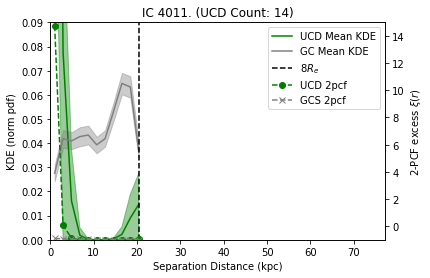

Galaxy IC 3976, UCD count:6
Galaxy NGC 4898, UCD count:6
Galaxy NGC 4869, UCD count:6
Galaxy IC 4051, UCD count:73


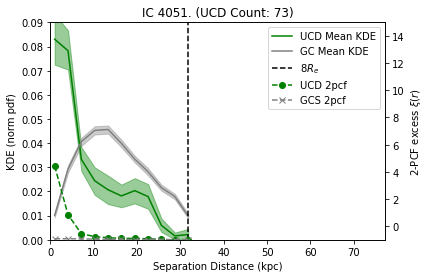

Galaxy IC 4045, UCD count:7
Galaxy NGC 4882, UCD count:26


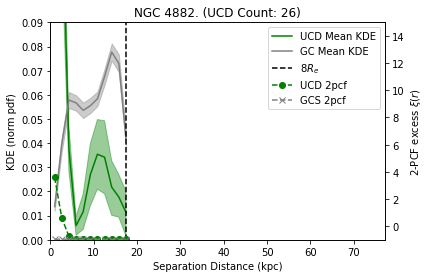

Galaxy NGC 4889, UCD count:135


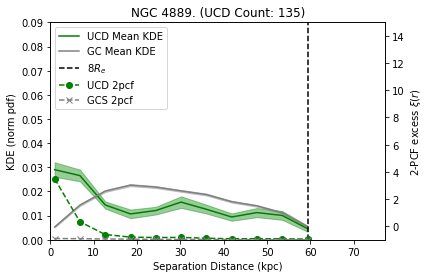

Galaxy NGC 4906, UCD count:8
Galaxy NGC 4867, UCD count:7
Galaxy NGC 4873, UCD count:25


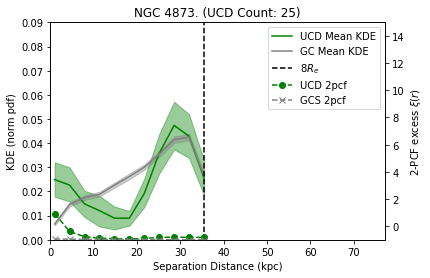

Galaxy NGC 4872, UCD count:7
Galaxy NGC 4871, UCD count:23


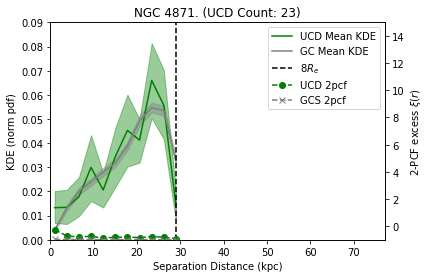

Galaxy NGC 4874, UCD count:120


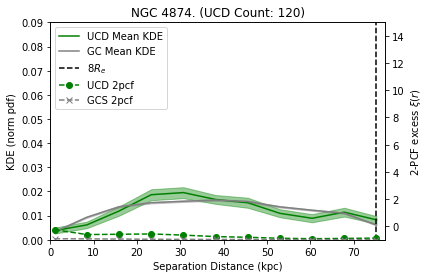

Galaxy IC 3998, UCD count:12


In [77]:
max_x = max(gal_2pc_df['bin_centers'])
ucd_min_count = 13
max_2pc = np.ceil(np.max(gal_2pc_df[gal_2pc_df['ucds_in_sample']>ucd_min_count]['xi_r_ucd']))
print(max_2pc)

for r in gal_2pc_df_sort['gal_name'].unique():
    df = gal_2pc_df[gal_2pc_df['gal_name']==r]
    ucd_total = max(df['ucds_in_sample'])
    print(f'Galaxy {r}, UCD count:{ucd_total}')
    if ucd_total>ucd_min_count:
        plot_2pcf_bootstrap_ci(df['bin_centers'], 
                               df['xi_r_ucd'], df['mean_kde_ucd'], df['xi_r_gcs'], df['mean_kde_gcs'], 
                               df['ci_lower_ucd'], df['ci_upper_ucd'], df['ci_lower_gcs'], df['ci_upper_gcs'], 
                               r, min_2pc=-1, max_2pc=max_2pc, max_x_range=max_x, ucd_total=ucd_total)



5.0
Galaxy IC 4011, UCD count:14
Galaxy IC 3976, UCD count:6
Galaxy NGC 4898, UCD count:6
Galaxy NGC 4869, UCD count:6
Galaxy IC 4051, UCD count:73
Galaxy IC 4045, UCD count:7
Galaxy NGC 4882, UCD count:26
Galaxy NGC 4889, UCD count:135
Galaxy NGC 4906, UCD count:8
Galaxy NGC 4867, UCD count:7
Galaxy NGC 4873, UCD count:25
Galaxy NGC 4872, UCD count:7
Galaxy NGC 4871, UCD count:23
Galaxy NGC 4874, UCD count:120
Galaxy IC 3998, UCD count:12


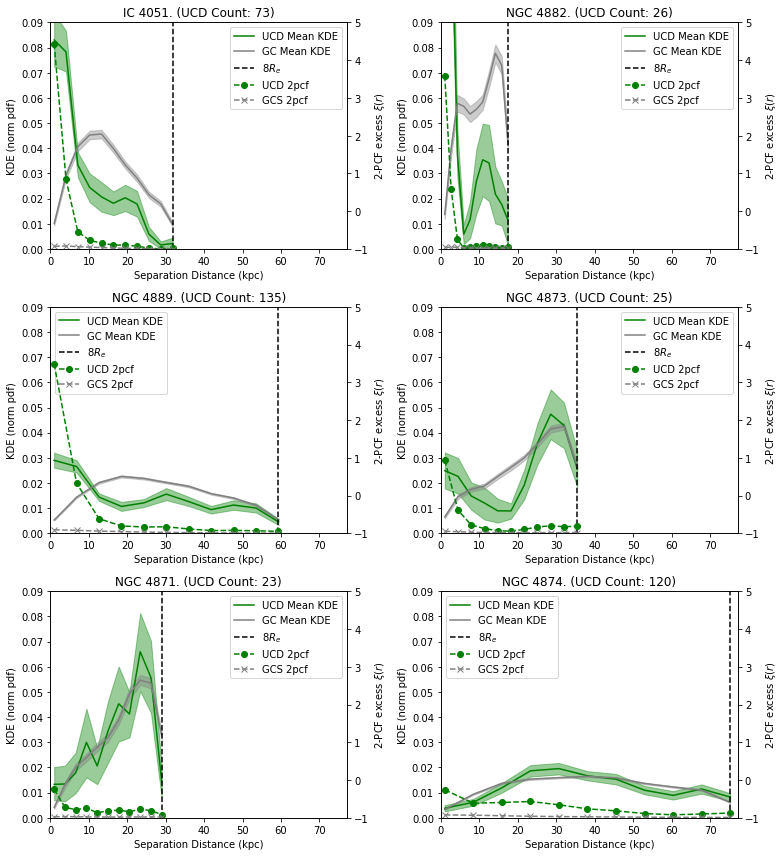

In [79]:
max_x = max(gal_2pc_df['bin_centers'])
ucd_min_count = 15
max_2pc = np.ceil(np.max(gal_2pc_df[gal_2pc_df['ucds_in_sample']>ucd_min_count]['xi_r_ucd']))
print(max_2pc)
i=0

# Create the grid
fig = plt.figure(figsize=(11, 12))
gs = GridSpec(3, 2, figure=fig)

# Loop through galaxies and plot each
# for i, gal_name in enumerate(galaxies):
for r in gal_2pc_df_sort['gal_name'].unique():
    df = gal_2pc_df[gal_2pc_df['gal_name']==r]
    ucd_total = max(df['ucds_in_sample'])
    print(f'Galaxy {r}, UCD count:{ucd_total}')
    if ucd_total>ucd_min_count:
        row, col = divmod(i, 2)
        ax = fig.add_subplot(gs[row, col])
        i += 1
        plot_2pcf_bootstrap_ci(df['bin_centers'], 
                               df['xi_r_ucd'], df['mean_kde_ucd'], df['xi_r_gcs'], df['mean_kde_gcs'], 
                               df['ci_lower_ucd'], df['ci_upper_ucd'], df['ci_lower_gcs'], df['ci_upper_gcs'], 
                               r, min_2pc=-1, max_2pc=max_2pc, max_x_range=max_x, ucd_total=ucd_total, ax=ax)

# Adjust layout
plt.tight_layout()
plt.savefig('figures/location/Coma_UCDs_Location_2pcf_Grid.png', dpi=300, bbox_inches='tight')
plt.show()


5.0
Galaxy IC 4011, UCD count:14
Galaxy IC 3976, UCD count:6
Galaxy NGC 4898, UCD count:6
Galaxy NGC 4869, UCD count:6
Galaxy IC 4051, UCD count:73
Galaxy IC 4045, UCD count:7
Galaxy NGC 4882, UCD count:26
Galaxy NGC 4889, UCD count:135
Galaxy NGC 4906, UCD count:8
Galaxy NGC 4867, UCD count:7
Galaxy NGC 4873, UCD count:25
Galaxy NGC 4872, UCD count:7
Galaxy NGC 4871, UCD count:23
Galaxy NGC 4874, UCD count:120
Galaxy IC 3998, UCD count:12


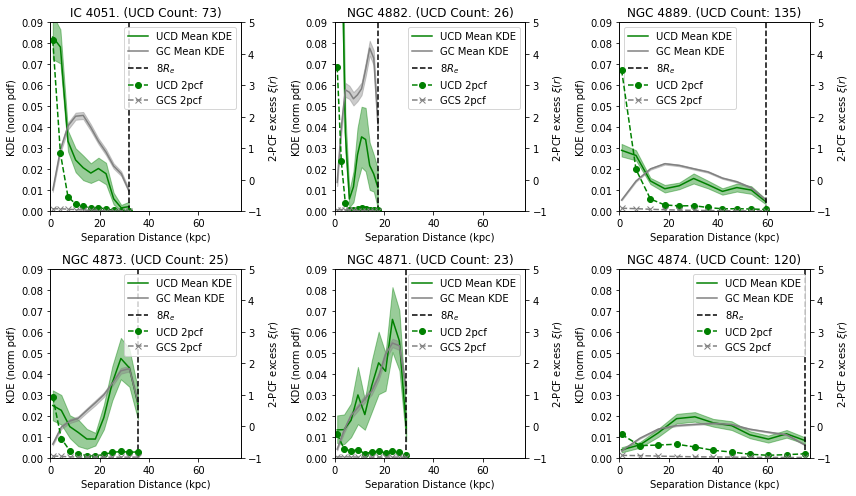

In [87]:
max_x = max(gal_2pc_df['bin_centers'])
ucd_min_count = 15
max_2pc = np.ceil(np.max(gal_2pc_df[gal_2pc_df['ucds_in_sample']>ucd_min_count]['xi_r_ucd']))
print(max_2pc)
i=0
row_tot=2
col_tot=3

# Create the grid
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(row_tot, col_tot, figure=fig)

# Loop through galaxies and plot each
# for i, gal_name in enumerate(galaxies):
for r in gal_2pc_df_sort['gal_name'].unique():
    df = gal_2pc_df[gal_2pc_df['gal_name']==r]
    ucd_total = max(df['ucds_in_sample'])
    print(f'Galaxy {r}, UCD count:{ucd_total}')
    if ucd_total>ucd_min_count:
        row, col = divmod(i, col_tot)
        ax = fig.add_subplot(gs[row, col])
        i += 1
        plot_2pcf_bootstrap_ci(df['bin_centers'], 
                               df['xi_r_ucd'], df['mean_kde_ucd'], df['xi_r_gcs'], df['mean_kde_gcs'], 
                               df['ci_lower_ucd'], df['ci_upper_ucd'], df['ci_lower_gcs'], df['ci_upper_gcs'], 
                               r, min_2pc=-1, max_2pc=max_2pc, max_x_range=max_x, ucd_total=ucd_total, ax=ax)

# Adjust layout
plt.tight_layout()
plt.savefig('figures/location/Coma_UCDs_Location_2pcf_Grid_3-col.png', dpi=300, bbox_inches='tight')
plt.show()


In [68]:
twopcf_kde_correlation_df = gal_2pc_df[gal_2pc_df['bin_centers']==1.00]
twopcf_kde_correlation_df


,gal_name,Mv,bin_centers,xi_r_ucd,mean_kde_ucd,xi_r_gcs,mean_kde_gcs,ci_lower_ucd,ci_upper_ucd,ci_lower_gcs,ci_upper_gcs,ucds_in_sample
0,IC 3998,14.57,1.0,-0.997690,0.000025,-0.973274,0.003140,8.739459e-21,0.000035,0.002422,0.003824,10
11,IC 4011,15.12,1.0,17.952844,0.477273,-0.902566,0.025368,1.308656e-01,1.050976,0.022371,0.028504,10
22,IC 4051,13.63,1.0,4.686527,0.069353,-0.926289,0.009810,5.914747e-02,0.080431,0.008953,0.010616,61
33,NGC 4871,14.14,1.0,0.022000,0.014671,-0.973055,0.004146,7.795650e-03,0.022325,0.003546,0.004780,20
44,NGC 4873,14.11,1.0,1.635487,0.027427,-0.942053,0.006559,1.818217e-02,0.036762,0.005905,0.007180,20
55,NGC 4874,11.68,1.0,-0.068668,0.003725,-0.922081,0.003315,2.425266e-03,0.005062,0.003174,0.003458,101
66,NGC 4882,13.86,1.0,3.666475,0.149532,-0.961187,0.013338,1.164015e-01,0.180738,0.011716,0.015013,21
77,NGC 4889,11.49,1.0,3.338450,0.023653,-0.911764,0.005098,2.045810e-02,0.026754,0.004874,0.005318,95
88,NGC 4906,14.10,1.0,4.041794,0.064406,-0.777035,0.030951,2.438991e-08,0.147039,0.027098,0.034744,7


0.7607598167182666 12.99016976165958 IC 3976
1.653998758182084e-05 -0.9988586168859321 IC 3998
0.43400318928478854 12.334962182031733 IC 4011
2.658177528046337e-06 -0.9999304744594807 IC 4045
0.08242175524943904 3.9317284362778606 IC 4051
0.30518821172757243 2.5206264482721163 NGC 4867
0.21091816082703466 6.444686595165148 NGC 4869
0.013700799107085871 -0.2893346434601197 NGC 4871
0.15283830195318066 0.6187893550474788 NGC 4872
0.025504211078887735 0.7976229051432997 NGC 4873
0.003703974411868326 -0.1319536818364695 NGC 4874
0.02899200846725852 3.694444214626275 NGC 4889
0.015209117210084106 -0.6515992146300922 NGC 4898
0.06934134106799861 3.424366554776525 NGC 4906


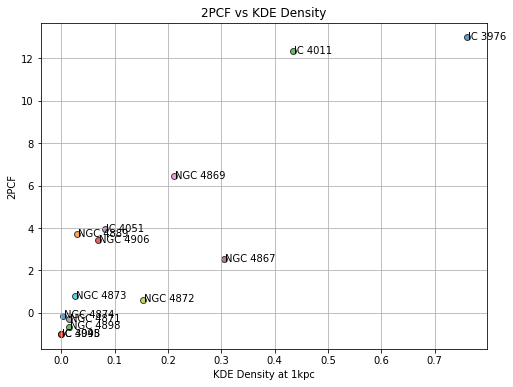

In [39]:

# # Example data
# gal_2pc_df['xi_r_ucd']  # Your 2-point correlation values
# gal_2pc_df['mean_kde_ucd']  # KDE density values at the central point

# Scatter plot
plt.figure(figsize=(8, 6))
xs = np.array(twopcf_kde_correlation_df['mean_kde_ucd'])
ys = np.array(twopcf_kde_correlation_df['xi_r_ucd'])
ts = np.array(twopcf_kde_correlation_df['gal_name'])
for x, y, t in zip(xs, ys, ts):
    print(x, y, t)
#     print(len(x), len(y), len(t))
    plt.scatter(x, y, alpha=0.7, edgecolor='k')
    plt.text(x + 0.002, y - 0.1, t, fontsize=10)
plt.xlabel('KDE Density at 1kpc')
plt.ylabel('2PCF')
plt.title('2PCF vs KDE Density')
plt.grid()
plt.show()


In [25]:
# print(ucd_coords)
# print(galaxy_coords)

random_ucd_coords = generate_random_positions(ucd_coords, galaxy_coords)

calculate_angular_separation(100000, 100e6)/3600


NameError: name 'ucd_coords' is not defined

In [33]:
def display_coma_gal(gal_name, fov_kpc):
    # Get galaxy coords and UCD / GC positions from dataframe
    galaxy_coords = get_gal_coords(gal_name)
    print(galaxy_coords)
    phi = [calculate_angular_separation(100, 100000)]

    # Display the image with RA/Dec coordinates
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection=wcs)  # Use the WCS from the FITS file

    # Apply asinh scaling using ImageNormalize and AsinhStretch
    norm = ImageNormalize(vmin=np.percentile(image_data, 0.1), 
                          vmax=np.percentile(image_data, 99.8), 
                          stretch=AsinhStretch(0.1))

    # Display the image with WCS coordinates and asinh scaling
    im = ax.imshow(image_data, origin='lower', cmap='gray', norm=norm)

    # Customize the coordinate grid and labels
    ax.coords.grid(color='gray', ls='dotted')
    ax.coords[0].set_axislabel('R.A. (J2000 deg)', fontsize=fs)
    ax.coords[1].set_axislabel('Dec. (J2000 deg)', fontsize=fs)

    # Explicitly set the number of ticks
    ax.coords[0].set_ticks(spacing=5 * u.arcmin)  # Set 5 RA ticks with 0.01 degree spacing
    ax.coords[1].set_ticks(spacing=5 * u.arcmin)  # Set 5 Dec ticks with 0.01 degree spacing

    # Adjust the ticks and tick labels if necessary
    ax.coords[0].set_major_formatter('dd:mm')
    ax.coords[1].set_major_formatter('dd:mm')
    ax.tick_params(axis='both', which='major', labelsize=fs)

    # Set desired limits in WCS (RA, Dec) based on galaxy center, and fov passed
    ra_min, ra_max = 195.30, 194.72  # RA limits in degrees or 13h01m12s to 12h58m52.8s
    dec_min, dec_max = 27.795, 28.20  # Dec limits in degrees
    fov_deg = calculate_angular_separation(fov_kpc, 100e3)/3600
#     ra_min, ra_max = galaxy_coords.ra.value + fov_deg, galaxy_coords.ra.value - fov_deg
#     dec_min, dec_max = galaxy_coords.dec.value - fov_deg, galaxy_coords.dec.value + fov_deg
    print(f'RA: {ra_min}-{ra_max}')
    print(f'Dec: {dec_min}-{dec_max}')


    # ax.scatter(gcs_df['x_wcs'], gcs_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=2, alpha = 0.4, color = 'r')
    ax.scatter(ucd_df['x_wcs'], ucd_df['y_wcs'], transform=ax.get_transform('world'), marker = '.', s=10, alpha = 0.8, color = 'r')
    pix_min = wcs.world_to_pixel_values(ra_min, dec_min)
    pix_max = wcs.world_to_pixel_values(ra_max, dec_max)

    # overlay galaxy names
    for i,name in enumerate(galaxies['galname']):
#         ax.scatter(galaxies['x_wcs'][i], galaxies['y_wcs'][i], transform=ax.get_transform('world'), color = 'r', marker = '.')
        ax.text(galaxies['x_wcs'][i], galaxies['y_wcs'][i], name, transform=ax.get_transform('world'), horizontalalignment = 'center', 
                 verticalalignment = 'bottom', fontsize=10, color='w')
        if not (main_galaxies3[main_galaxies3['name']==name].empty):
    #         add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], float(main_galaxies[main_galaxies['name']==name]['gal_Re']), ax, '-')
            [add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], ang, ax, '--') for j, ang in enumerate(phi)]
    #             add_effective_radius(galaxies['x_wcs'][i], galaxies['y_wcs'][i], theta[0], ax, '-')

    # Set pixel limits directly
    ax.set_xlim(pix_min[0], pix_max[0])
    ax.set_ylim(pix_min[1], pix_max[1])

    # Add a scale marker (e.g., 60 arcseconds = 1 arcminute)
    length_arcsec = calculate_angular_separation(100e3, 100e6)
    add_scale_bar(ax, wcs, length_arcsec=length_arcsec, label="100 kpc", color='white', fontsize=11)  

    # Add a colorbar
    path = 'figures/location/'
    plt.savefig(f'{path}Coma_UCDs_Location_Re_{idlabel}.png', bbox_inches='tight', format='png', dpi=200)
    plt.show()


<SkyCoord (ICRS): (ra, dec) in deg
    (194.89875, 27.959223)>
RA: 195.3-194.72
Dec: 27.795-28.2


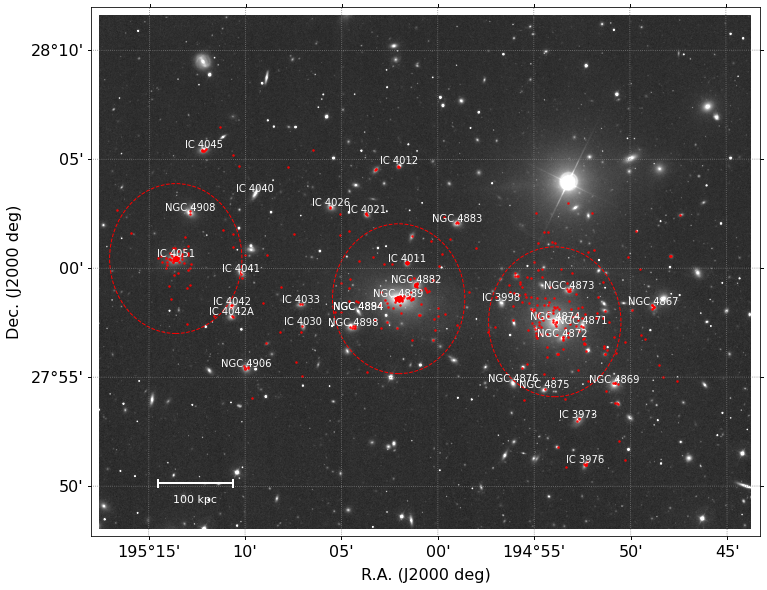

In [34]:
display_coma_gal('NGC 4874', 110)
